# Deep-Dive Analysis — Electoral Volatility & Demographic Misfits

**Author:** Antoni Czolgowski  
**Course:** CSCI 5502 Data Mining — Spring 2026  

---

This notebook extends the classification analysis with deeper explorations:

1. **Why do demographic misfits tend to be volatile?** — County profiling
2. **State-specific models** — Per-state classifiers since LOSO failed
3. **SHAP interaction effects** — Feature combinations that drive volatility
4. **Binary classification** — High vs Low volatility (cleaner signal, ROC-AUC ~0.80)
5. **Campaign strategist view** — Misfit × Volatility × Vote Volume
6. **Nonlinear deep-dives** — Exploring the rent-volatility curve and other nonlinearities

**Prerequisite:** Run `classification_antoni.ipynb` first — this notebook loads its outputs.

In [1]:
import numpy as np
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    StratifiedKFold, RandomizedSearchCV, cross_val_predict, cross_val_score
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay, precision_recall_curve, average_precision_score
)

import xgboost as xgb
import shap

from scipy.stats import pearsonr, spearmanr, mannwhitneyu, kruskal
from itertools import combinations

RANDOM_STATE = 42
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150

BASE = '../data/processed'
FIG_DIR = '../docs/images/methods'
os.makedirs(FIG_DIR, exist_ok=True)

print('Imports loaded.')

Imports loaded.


## 0. Reload Data from Main Notebook

In [2]:
master_raw = pd.read_csv(f'{BASE}/master_dataset.csv', dtype={'county_fips': str})
master_scaled = pd.read_csv(f'{BASE}/master_dataset_scaled.csv', dtype={'county_fips': str})
volatility = pd.read_csv(f'{BASE}/county_volatility_dimTable.csv', dtype={'county_fips': str})
predictions = pd.read_csv(f'{BASE}/classification_predictions.csv', dtype={'county_fips': str})
class_dataset = pd.read_csv(f'{BASE}/classification_dataset_250.csv', dtype={'county_fips': str})

for df_ in [master_raw, master_scaled, volatility, predictions, class_dataset]:
    df_['county_fips'] = df_['county_fips'].astype(str).str.zfill(5)

df_2024 = master_raw[master_raw['election_year'] == 2024].copy().reset_index(drop=True)
df_2024['county_fips'] = df_2024['county_fips'].str.zfill(5)

entropy_2024 = master_scaled[master_scaled['election_year'] == 2024][['county_fips', 'race_entropy_norm']].copy()

df = df_2024.merge(volatility[['county_fips', 'vol_z_abs_sum', 'swing_dir_score', 'vol_z_euc']],
                   on='county_fips', how='left')
df = df.merge(entropy_2024, on='county_fips', how='left')
df = df.merge(predictions[['county_fips', 'actual_quintile', 'xgb_pred', 'rf_pred', 'svm_pred',
                            'p_dem', 'misfit_score', 'abs_margin_residual']],
              on='county_fips', how='left')

df['volatility_class'] = pd.qcut(df['vol_z_abs_sum'], q=5,
    labels=['Very Stable', 'Stable', 'Moderate', 'Volatile', 'Highly Volatile'])
df['vol_quintile_num'] = pd.qcut(df['vol_z_abs_sum'], q=5, labels=False) + 1
df['vol_binary'] = (df['vol_quintile_num'] >= 4).astype(int)
df['dem_winner'] = (df['dem_margin'] > 0).astype(int)

exclude_cols = [
    'county_fips', 'state', 'county_name', 'election_year',
    'dem_votes', 'rep_votes', 'total_votes', 'dem_pct', 'rep_pct', 'dem_margin',
    'vol_z_abs_sum', 'vol_z_euc', 'swing_dir_score',
    'volatility_class', 'vol_quintile_num', 'vol_binary', 'dem_winner',
    'actual_quintile', 'xgb_pred', 'rf_pred', 'svm_pred',
    'p_dem', 'misfit_score', 'abs_margin_residual'
]

feature_cols = [c for c in df.columns if c not in exclude_cols]

log_cols = ['total_population', 'population_density',
            'median_household_income', 'median_home_value', 'median_gross_rent']

df_features = df[feature_cols].copy()
for col in log_cols:
    if col in df_features.columns:
        df_features[f'log_{col}'] = np.log1p(df_features[col])
        df_features.drop(columns=[col], inplace=True)

drop_multi = ['pct_income_over_100k']
from scipy.stats import pearsonr as _pr
if 'pct_non_hispanic_white' in df_features.columns and 'race_entropy_norm' in df_features.columns:
    r_, _ = _pr(df_features['pct_non_hispanic_white'], df_features['race_entropy_norm'])
    if abs(r_) > 0.85:
        drop_multi.append('pct_non_hispanic_white')
df_features.drop(columns=[c for c in drop_multi if c in df_features.columns], inplace=True)

feature_names = list(df_features.columns)
X_unscaled = df_features.copy()

scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(df_features), columns=feature_names)

y = df['vol_quintile_num'].values
y_binary = df['vol_binary'].values
state_series = df['state'].copy()

print(f'Loaded: {X.shape[0]} counties, {X.shape[1]} features')
print(f'Predictions columns: {list(predictions.columns)}')

Loaded: 250 counties, 28 features
Predictions columns: ['county_fips', 'state', 'county_name', 'actual_quintile', 'rf_pred', 'xgb_pred', 'svm_pred', 'p_dem', 'misfit_score', 'abs_margin_residual']


---
## 1. Why Do Demographic Misfits Tend to Be Volatile?

We found Spearman rho = 0.408 between misfit score and volatility. Let's understand WHY.

### 1.1 Misfit Profile Comparison

In [3]:
misfit_threshold = df['misfit_score'].quantile(0.80)
df['is_misfit'] = (df['misfit_score'] >= misfit_threshold).astype(int)

print(f'Misfit threshold (80th percentile): {misfit_threshold:.4f}')
print(f'Misfits: {df["is_misfit"].sum()}, Non-misfits: {(1-df["is_misfit"]).sum()}')

demo_compare = []
compare_features = ['race_entropy_norm', 'pct_below_poverty', 'pct_bachelors_plus',
                     'median_household_income', 'population_density', 'total_population',
                     'pct_black', 'pct_hispanic', 'unemployment_rate',
                     'pct_owner_occupied', 'median_gross_rent', 'pct_married_couple',
                     'pct_public_transit', 'pct_work_from_home', 'median_age']

for feat in compare_features:
    if feat in df.columns:
        misfits_vals = df.loc[df['is_misfit'] == 1, feat]
        non_misfits_vals = df.loc[df['is_misfit'] == 0, feat]
        stat, pval = mannwhitneyu(misfits_vals, non_misfits_vals, alternative='two-sided')
        demo_compare.append({
            'Feature': feat,
            'Misfit Mean': misfits_vals.mean(),
            'Non-Misfit Mean': non_misfits_vals.mean(),
            'Difference': misfits_vals.mean() - non_misfits_vals.mean(),
            'MW p-value': pval
        })

compare_df = pd.DataFrame(demo_compare).sort_values('MW p-value')
print('\n=== Demographic Profile: Misfits vs Non-Misfits ===')
print(compare_df.to_string(index=False, float_format='%.4f'))

Misfit threshold (80th percentile): 0.1789
Misfits: 50, Non-misfits: 200

=== Demographic Profile: Misfits vs Non-Misfits ===
                Feature  Misfit Mean  Non-Misfit Mean  Difference  MW p-value
     pct_owner_occupied      71.1317          76.2649     -5.1332      0.0000
     pct_bachelors_plus      30.8543          24.6551      6.1992      0.0000
      race_entropy_norm       0.5667           0.4190      0.1478      0.0000
      median_gross_rent    1056.4800         931.9350    124.5450      0.0000
              pct_black      16.0729           8.6033      7.4696      0.0001
     population_density     303.1728         274.6905     28.4823      0.0007
           pct_hispanic       8.3748           5.8287      2.5461      0.0012
             median_age      42.4960          44.4965     -2.0005      0.0027
     pct_work_from_home      11.4885          10.0313      1.4573      0.0037
       total_population  160949.7800      128896.5750  32053.2050      0.0102
     pct_married

### 1.2 Misfit Types — Which Way Do They Defy Expectations?

In [4]:
df['class_residual'] = df['dem_winner'] - df['p_dem']

top_misfits = df.nlargest(30, 'misfit_score').copy()
top_misfits['misfit_type'] = np.where(
    top_misfits['class_residual'] > 0,
    'Surprise Dem (demographics say Rep)',
    'Surprise Rep (demographics say Dem)'
)

type_counts = top_misfits['misfit_type'].value_counts()
print('Top 30 Misfits by type:')
print(type_counts)

for mtype in type_counts.index:
    subset = top_misfits[top_misfits['misfit_type'] == mtype]
    print(f'\n--- {mtype} ---')
    print(f'  Avg volatility (vol_z_abs_sum): {subset["vol_z_abs_sum"].mean():.3f}')
    print(f'  Avg population: {subset["total_population"].mean():,.0f}')
    print(f'  Avg race_entropy_norm: {subset["race_entropy_norm"].mean():.3f}')
    print(f'  Avg pct_bachelors_plus: {subset["pct_bachelors_plus"].mean():.1f}%')
    print(f'  States: {dict(subset["state"].value_counts())}')
    print(f'  Counties: {", ".join(subset["county_name"].values[:8])}')

Top 30 Misfits by type:
misfit_type
Surprise Rep (demographics say Dem)    22
Surprise Dem (demographics say Rep)     8
Name: count, dtype: int64

--- Surprise Rep (demographics say Dem) ---
  Avg volatility (vol_z_abs_sum): 0.383
  Avg population: 141,057
  Avg race_entropy_norm: 0.564
  Avg pct_bachelors_plus: 31.6%
  States: {'NC': np.int64(11), 'MI': np.int64(7), 'PA': np.int64(4)}
  Counties: Nash County, Lenoir County, Cabarrus County, Isabella County, Wayne County, Moore County, Bucks County, Scotland County

--- Surprise Dem (demographics say Rep) ---
  Avg volatility (vol_z_abs_sum): 0.807
  Avg population: 117,468
  Avg race_entropy_norm: 0.563
  Avg pct_bachelors_plus: 32.0%
  States: {'NC': np.int64(4), 'MI': np.int64(3), 'PA': np.int64(1)}
  Counties: Leelanau County, Marquette County, Genesee County, Lackawanna County, Chatham County, Hoke County, Bertie County, Wilson County


### 1.3 Misfit Score Distribution by Volatility Class

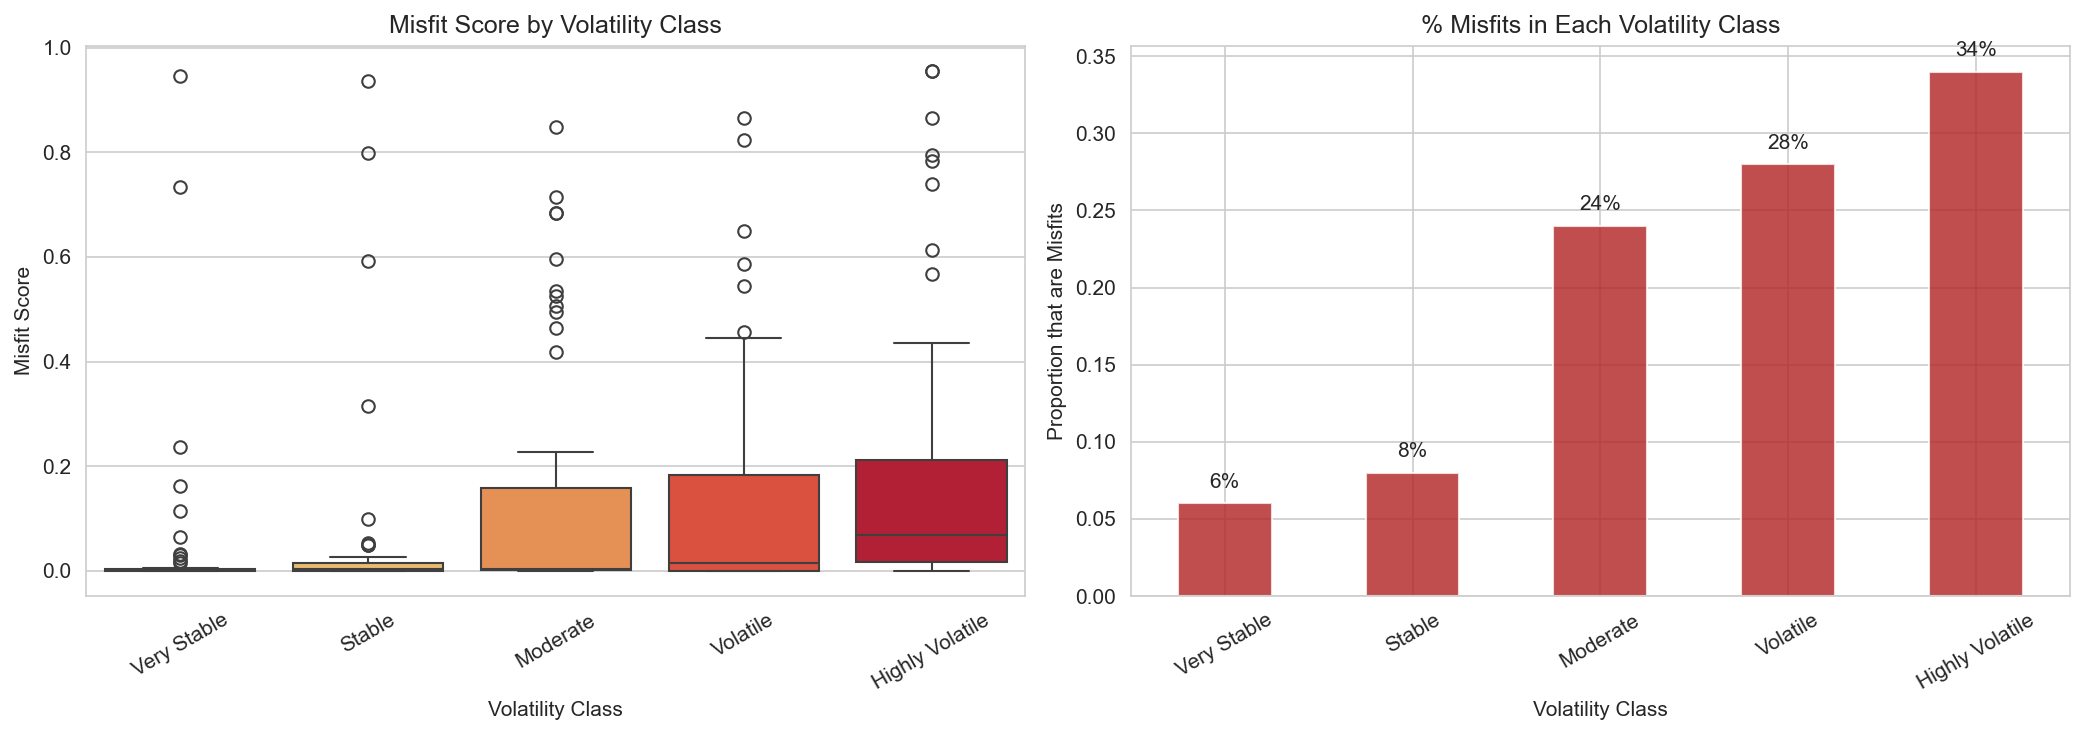

Kruskal-Wallis test (misfit score across volatility classes): H=41.54, p=0.000000


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = ['Very Stable', 'Stable', 'Moderate', 'Volatile', 'Highly Volatile']
sns.boxplot(data=df, x='volatility_class', y='misfit_score', order=order, ax=axes[0],
            palette='YlOrRd')
axes[0].set_title('Misfit Score by Volatility Class')
axes[0].set_xlabel('Volatility Class')
axes[0].set_ylabel('Misfit Score')
axes[0].tick_params(axis='x', rotation=30)

ct = pd.crosstab(df['volatility_class'], df['is_misfit'], normalize='index')
ct = ct.reindex(order)
ct.columns = ['Non-Misfit', 'Misfit']
ct['Misfit'].plot(kind='bar', ax=axes[1], color='firebrick', alpha=0.8)
axes[1].set_title('% Misfits in Each Volatility Class')
axes[1].set_ylabel('Proportion that are Misfits')
axes[1].set_xlabel('Volatility Class')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(ct['Misfit']):
    axes[1].text(i, v + 0.01, f'{v:.0%}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/deepdive_misfit_by_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

stat, pval = kruskal(*[df.loc[df['volatility_class'] == c, 'misfit_score'] for c in order])
print(f'Kruskal-Wallis test (misfit score across volatility classes): H={stat:.2f}, p={pval:.6f}')

---
## 2. State-Specific Models

Since LOSO showed demographics don't generalize across states (F1 dropped to ~0.19), let's train separate models per state and compare.

### 2.1 Per-State XGBoost with 5-Fold CV

In [6]:
state_results = {}

for state_name in ['PA', 'MI', 'NC']:
    mask = state_series == state_name
    X_state = X_unscaled[mask].copy()
    y_state = y[mask]
    n_state = mask.sum()
    
    n_classes = len(np.unique(y_state))
    present_classes = np.unique(y_state)
    
    state_scaler = StandardScaler()
    X_state_scaled = pd.DataFrame(
        state_scaler.fit_transform(X_state), columns=feature_names
    )
    
    y_state_bin = np.where(y_state >= 4, 1, 0)
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    
    xgb_state = xgb.XGBClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, verbosity=0,
        eval_metric='logloss'
    )
    
    scores_f1 = cross_val_score(xgb_state, X_state_scaled, y_state_bin, cv=cv, scoring='f1')
    scores_acc = cross_val_score(xgb_state, X_state_scaled, y_state_bin, cv=cv, scoring='accuracy')
    scores_auc = cross_val_score(xgb_state, X_state_scaled, y_state_bin, cv=cv, scoring='roc_auc')
    
    preds = cross_val_predict(xgb_state, X_state_scaled, y_state_bin, cv=cv)
    proba = cross_val_predict(xgb_state, X_state_scaled, y_state_bin, cv=cv, method='predict_proba')
    
    xgb_state.fit(X_state_scaled, y_state_bin)
    
    state_results[state_name] = {
        'n': n_state,
        'class_dist': dict(zip(*np.unique(y_state, return_counts=True))),
        'binary_dist': dict(zip(*np.unique(y_state_bin, return_counts=True))),
        'f1': scores_f1.mean(),
        'f1_std': scores_f1.std(),
        'acc': scores_acc.mean(),
        'auc': scores_auc.mean(),
        'model': xgb_state,
        'preds': preds,
        'proba': proba,
        'X': X_state_scaled,
        'y': y_state_bin
    }
    
    print(f'{state_name} (n={n_state}): '
          f'Binary dist={state_results[state_name]["binary_dist"]} | '
          f'F1={scores_f1.mean():.3f}+/-{scores_f1.std():.3f}, '
          f'Acc={scores_acc.mean():.3f}, '
          f'AUC={scores_auc.mean():.3f}')

PA (n=67): Binary dist={np.int64(0): np.int64(46), np.int64(1): np.int64(21)} | F1=0.591+/-0.312, Acc=0.805, AUC=0.838
MI (n=83): Binary dist={np.int64(0): np.int64(51), np.int64(1): np.int64(32)} | F1=0.636+/-0.156, Acc=0.757, AUC=0.778
NC (n=100): Binary dist={np.int64(0): np.int64(53), np.int64(1): np.int64(47)} | F1=0.736+/-0.123, Acc=0.750, AUC=0.829


### 2.2 Per-State Feature Importance Comparison

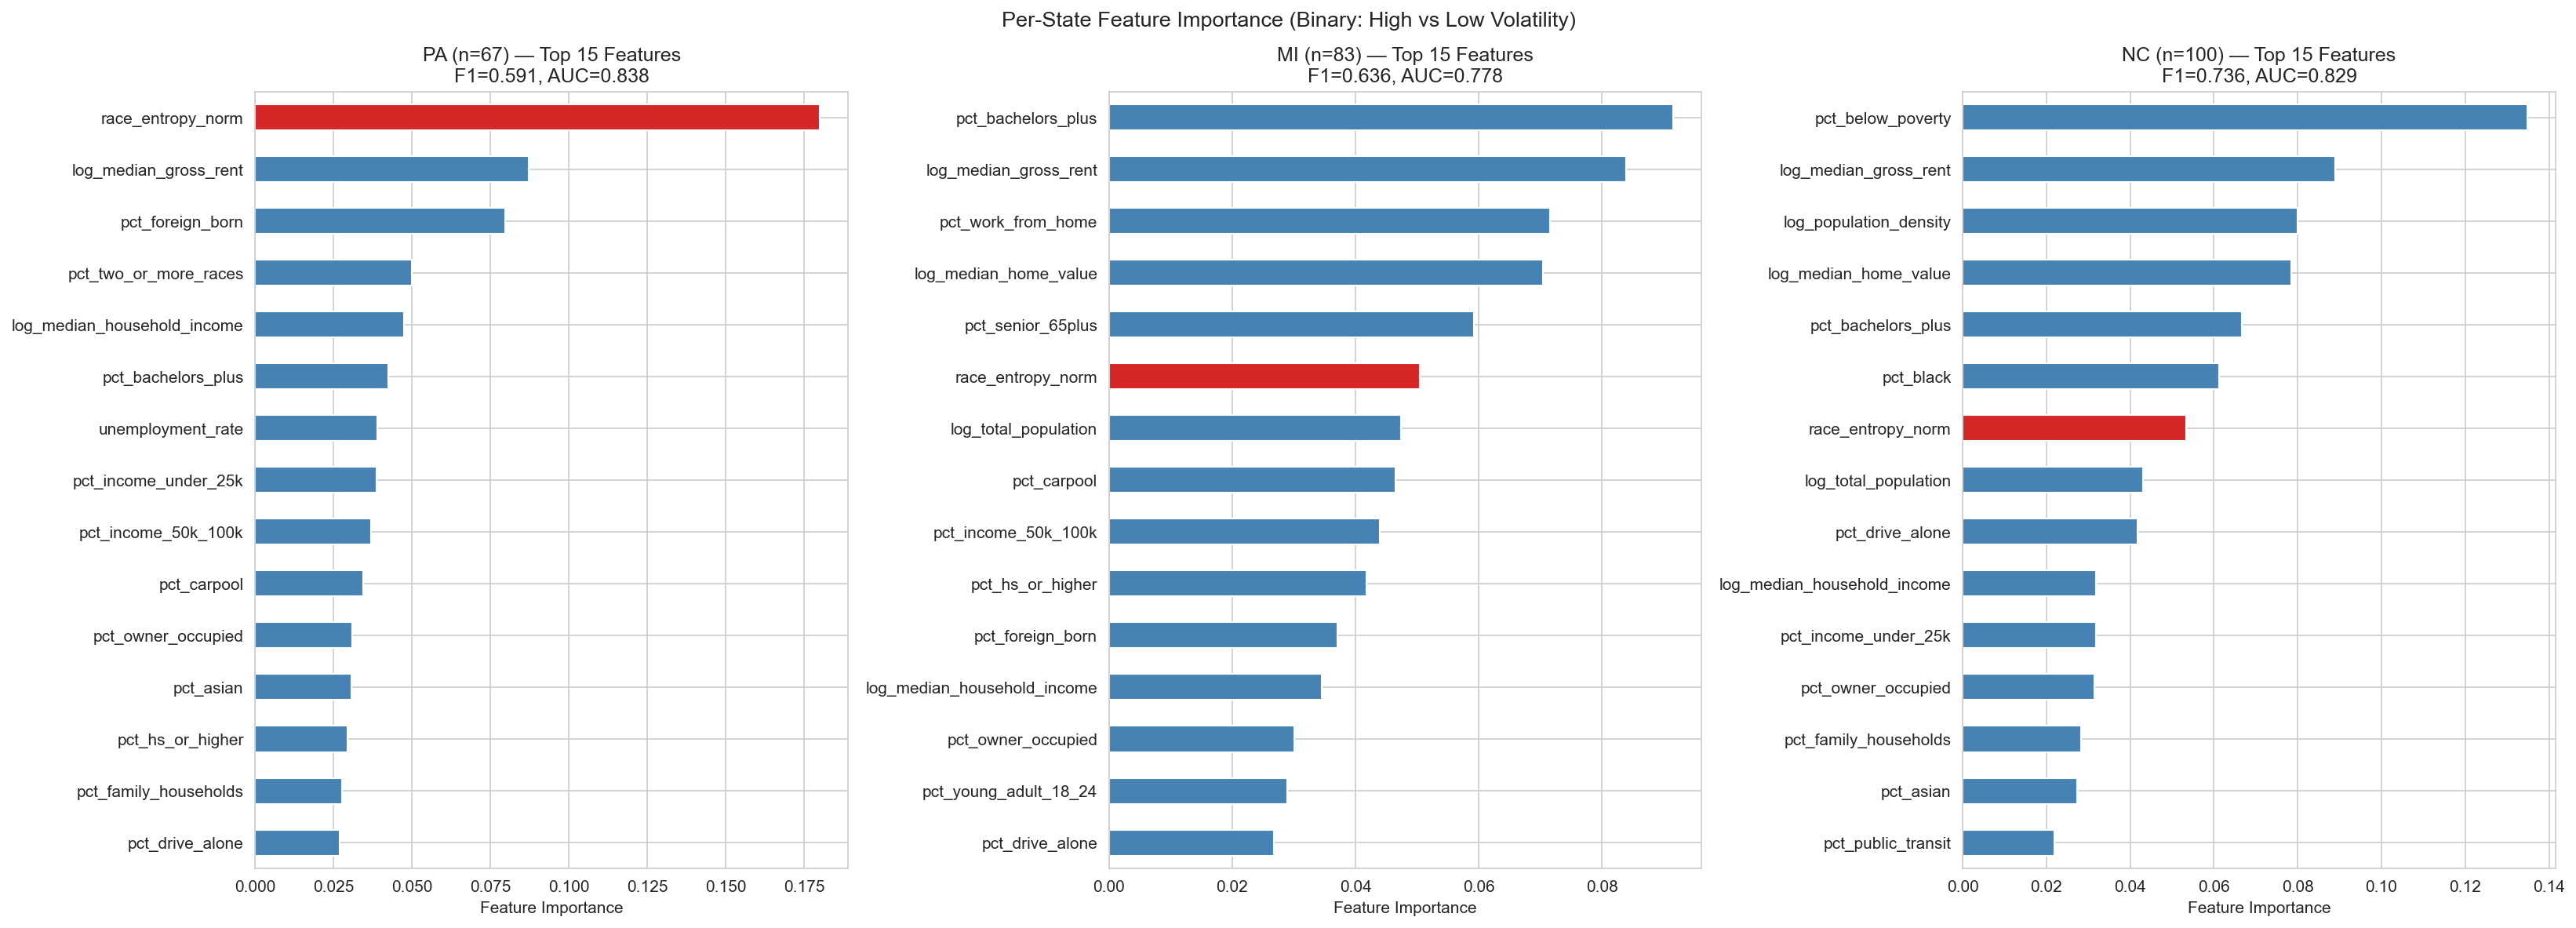


Top 5 features per state:
  PA: race_entropy_norm, log_median_gross_rent, pct_foreign_born, pct_two_or_more_races, log_median_household_income
  MI: pct_bachelors_plus, log_median_gross_rent, pct_work_from_home, log_median_home_value, pct_senior_65plus
  NC: pct_below_poverty, log_median_gross_rent, log_population_density, log_median_home_value, pct_bachelors_plus


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(22, 8))

for i, state_name in enumerate(['PA', 'MI', 'NC']):
    res = state_results[state_name]
    model = res['model']
    
    imp = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=True)
    imp.tail(15).plot(kind='barh', ax=axes[i], color=['#d62728' if 'entropy' in f else 'steelblue' for f in imp.tail(15).index])
    axes[i].set_title(f'{state_name} (n={res["n"]}) — Top 15 Features\nF1={res["f1"]:.3f}, AUC={res["auc"]:.3f}')
    axes[i].set_xlabel('Feature Importance')

plt.suptitle('Per-State Feature Importance (Binary: High vs Low Volatility)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/deepdive_state_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 features per state:')
for state_name in ['PA', 'MI', 'NC']:
    model = state_results[state_name]['model']
    imp = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)
    print(f'  {state_name}: {", ".join(imp.head(5).index)}')

### 2.3 State-Specific ROC Curves

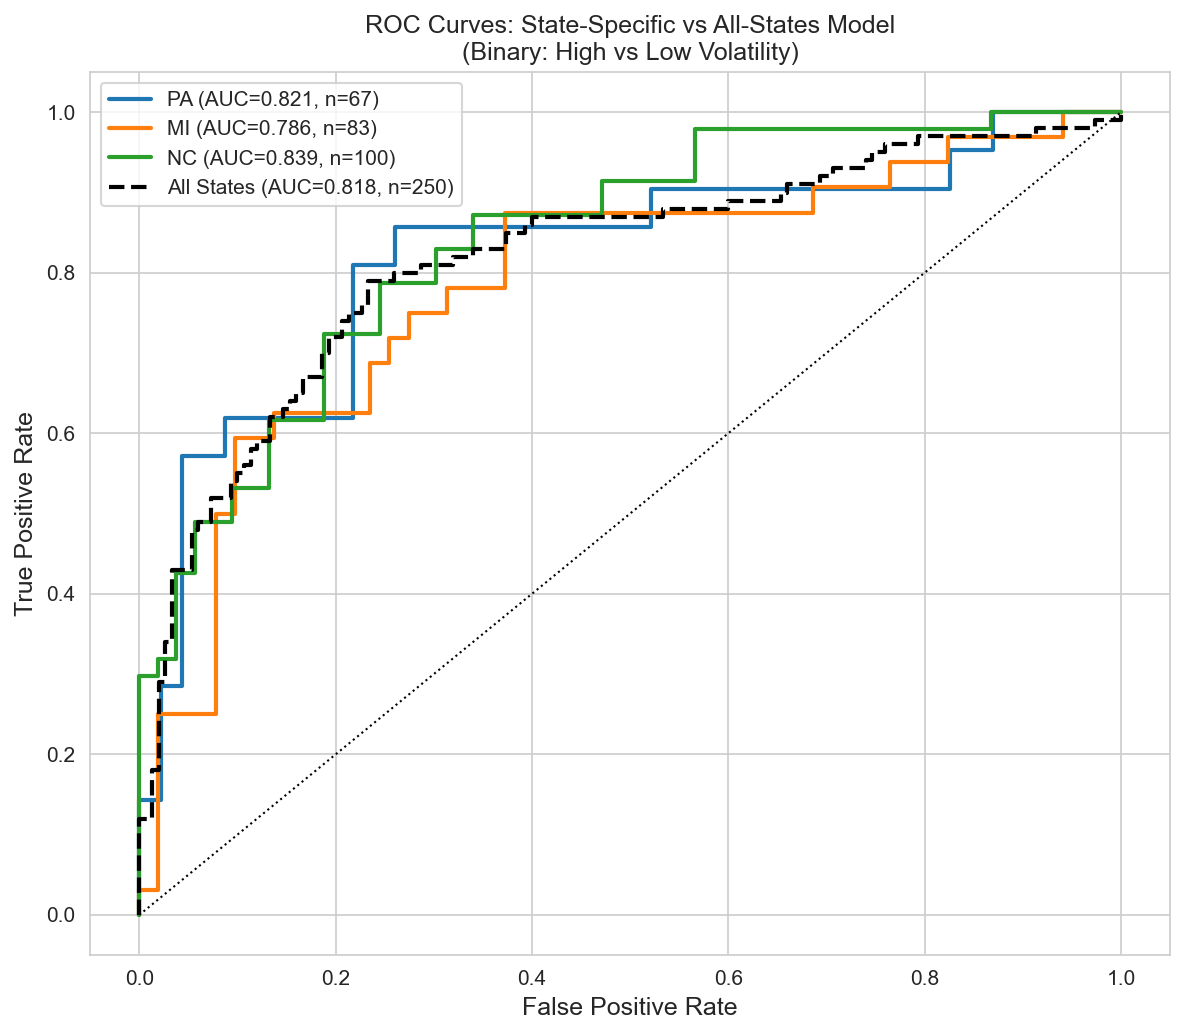

In [8]:
fig, ax = plt.subplots(figsize=(8, 7))
colors = {'PA': '#1f77b4', 'MI': '#ff7f0e', 'NC': '#2ca02c'}

for state_name in ['PA', 'MI', 'NC']:
    res = state_results[state_name]
    fpr, tpr, _ = roc_curve(res['y'], res['proba'][:, 1])
    auc_val = roc_auc_score(res['y'], res['proba'][:, 1])
    ax.plot(fpr, tpr, color=colors[state_name], lw=2,
            label=f'{state_name} (AUC={auc_val:.3f}, n={res["n"]})')

xgb_full = xgb.XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    random_state=RANDOM_STATE, verbosity=0, eval_metric='logloss'
)
cv_full = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
full_proba = cross_val_predict(xgb_full, X, y_binary, cv=cv_full, method='predict_proba')
fpr_f, tpr_f, _ = roc_curve(y_binary, full_proba[:, 1])
auc_f = roc_auc_score(y_binary, full_proba[:, 1])
ax.plot(fpr_f, tpr_f, color='black', lw=2, linestyle='--',
        label=f'All States (AUC={auc_f:.3f}, n=250)')

ax.plot([0, 1], [0, 1], 'k:', lw=1)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves: State-Specific vs All-States Model\n(Binary: High vs Low Volatility)', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/deepdive_state_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. SHAP Interaction Effects

Which feature **combinations** drive volatility predictions? SHAP interaction values reveal synergies between features.

### 3.1 Train Final XGBoost for SHAP Analysis

SHAP values shape: (250, 28)


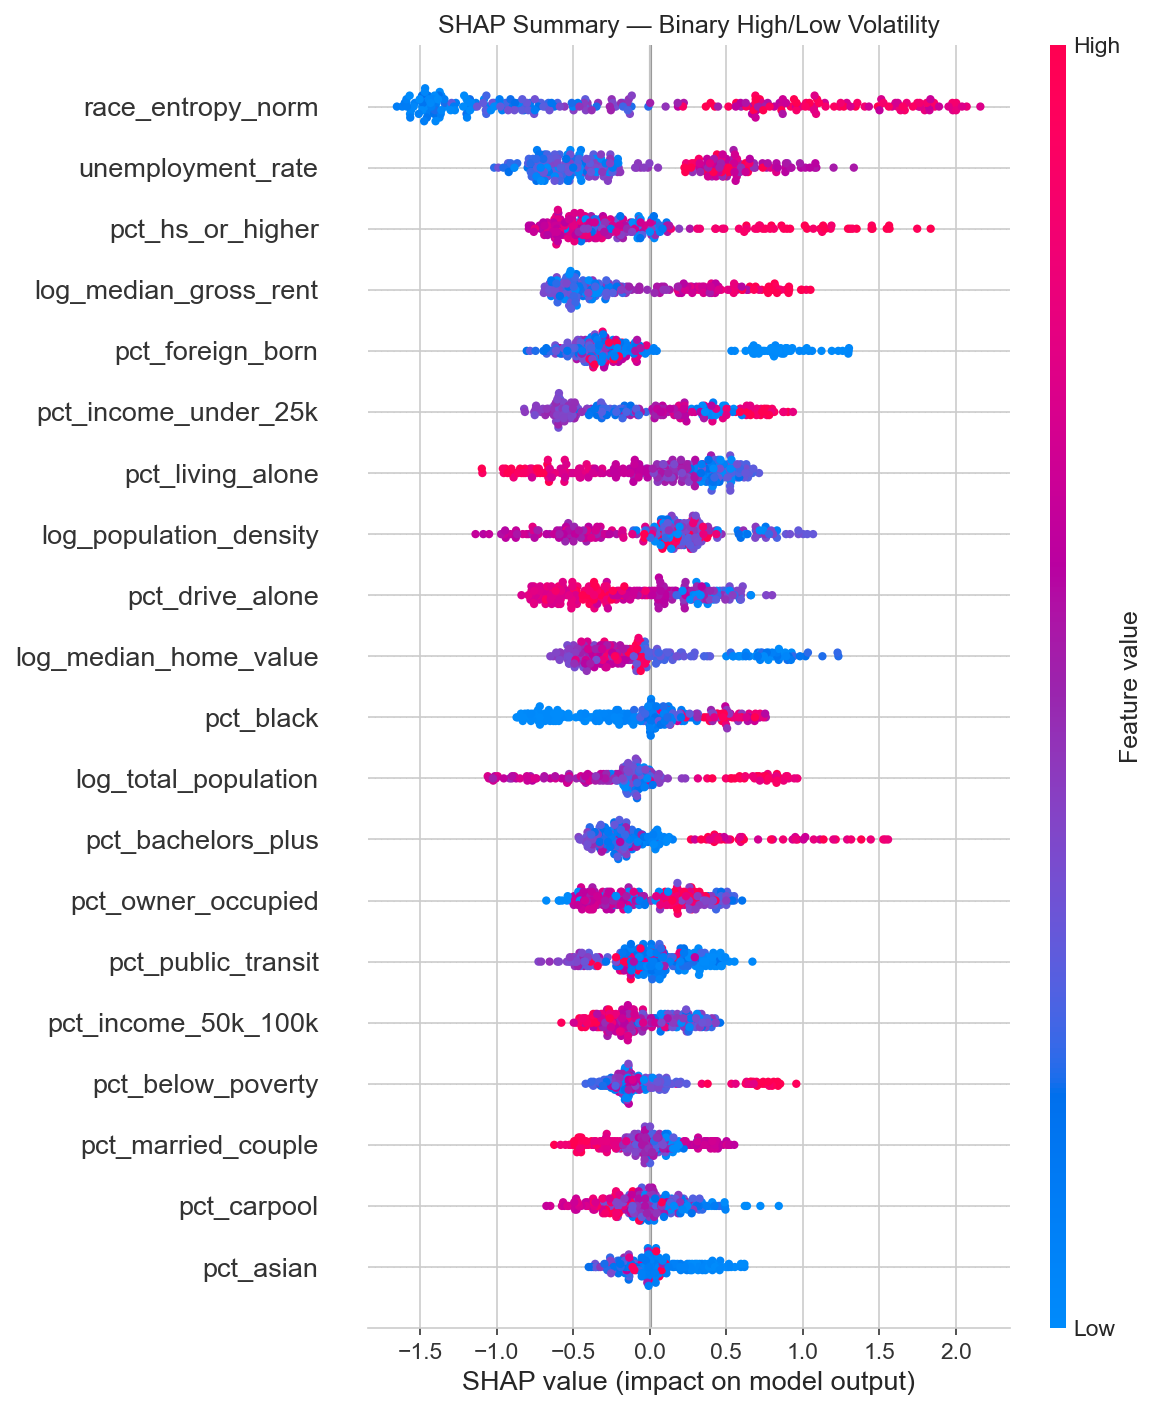

In [9]:
xgb_binary = xgb.XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_STATE, verbosity=0,
    eval_metric='logloss'
)
xgb_binary.fit(X, y_binary)

explainer = shap.TreeExplainer(xgb_binary)
shap_values = explainer.shap_values(X)

print(f'SHAP values shape: {shap_values.shape}')

shap.summary_plot(shap_values, X, feature_names=feature_names, show=False, max_display=20)
plt.title('SHAP Summary — Binary High/Low Volatility', fontsize=12)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/deepdive_shap_binary_summary.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 SHAP Interaction Values

In [10]:
print('Computing SHAP interaction values (may take a minute)...')
shap_interaction = explainer.shap_interaction_values(X)
print(f'Interaction values shape: {shap_interaction.shape}')

mean_interactions = np.abs(shap_interaction).mean(axis=0)
np.fill_diagonal(mean_interactions, 0)

interaction_df = pd.DataFrame(mean_interactions, index=feature_names, columns=feature_names)

top_interactions = []
for i, f1 in enumerate(feature_names):
    for j, f2 in enumerate(feature_names):
        if i < j:
            top_interactions.append((f1, f2, mean_interactions[i, j]))

top_interactions.sort(key=lambda x: x[2], reverse=True)
print('\nTop 15 Feature Interactions (mean |SHAP interaction|):')
print(f'{"Feature 1":<30} {"Feature 2":<30} {"Interaction":>12}')
print('-' * 74)
for f1, f2, val in top_interactions[:15]:
    print(f'{f1:<30} {f2:<30} {val:>12.4f}')

Computing SHAP interaction values (may take a minute)...
Interaction values shape: (250, 28, 28)

Top 15 Feature Interactions (mean |SHAP interaction|):
Feature 1                      Feature 2                       Interaction
--------------------------------------------------------------------------
race_entropy_norm              log_population_density               0.1328
pct_bachelors_plus             race_entropy_norm                    0.0908
log_total_population           log_population_density               0.0778
race_entropy_norm              log_total_population                 0.0691
pct_hs_or_higher               race_entropy_norm                    0.0574
pct_foreign_born               race_entropy_norm                    0.0520
pct_hs_or_higher               pct_income_50k_100k                  0.0481
unemployment_rate              log_population_density               0.0460
unemployment_rate              race_entropy_norm                    0.0459
pct_black             

### 3.3 Visualize Top Interactions

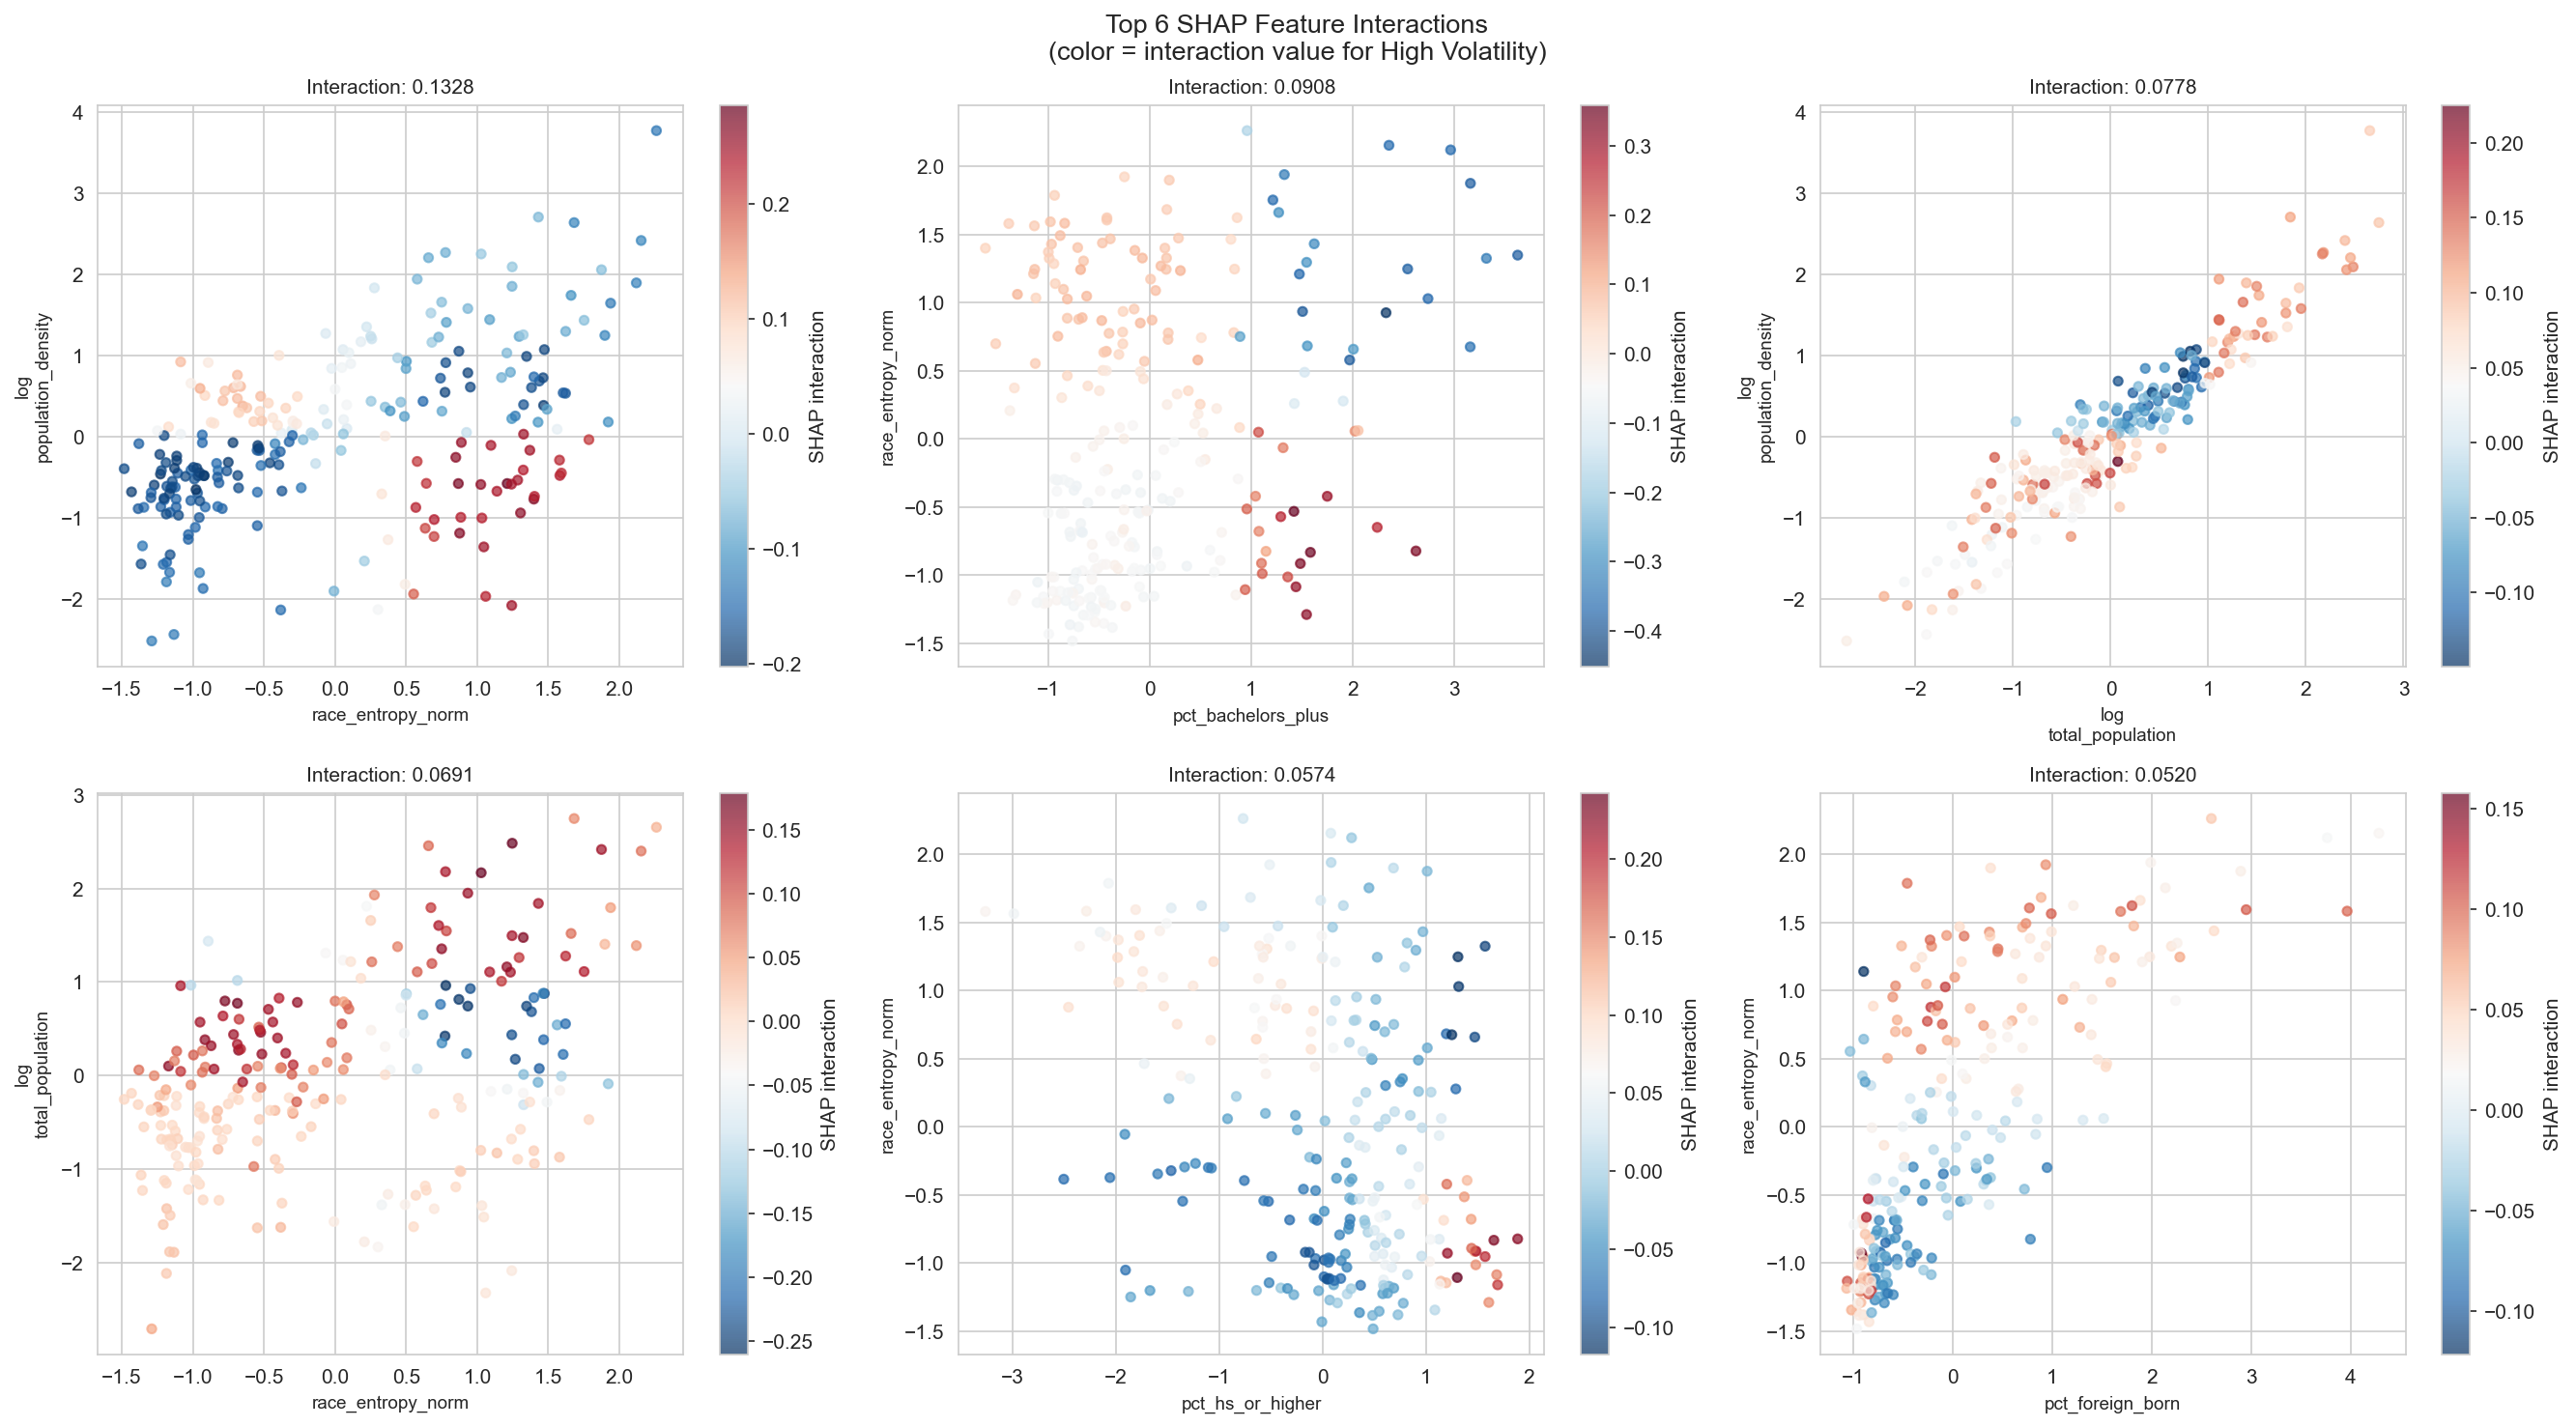

In [11]:
top6 = top_interactions[:6]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, (f1, f2, val) in enumerate(top6):
    ax = axes[idx // 3, idx % 3]
    i1 = feature_names.index(f1)
    i2 = feature_names.index(f2)
    
    scatter = ax.scatter(
        X[f1].values, X[f2].values,
        c=shap_interaction[:, i1, i2],
        cmap='RdBu_r', s=20, alpha=0.7
    )
    ax.set_xlabel(f1.replace('log_', 'log\n'), fontsize=9)
    ax.set_ylabel(f2.replace('log_', 'log\n'), fontsize=9)
    ax.set_title(f'Interaction: {val:.4f}', fontsize=10)
    plt.colorbar(scatter, ax=ax, label='SHAP interaction')

plt.suptitle('Top 6 SHAP Feature Interactions\n(color = interaction value for High Volatility)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/deepdive_shap_interactions.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Interaction Heatmap (Top Features)

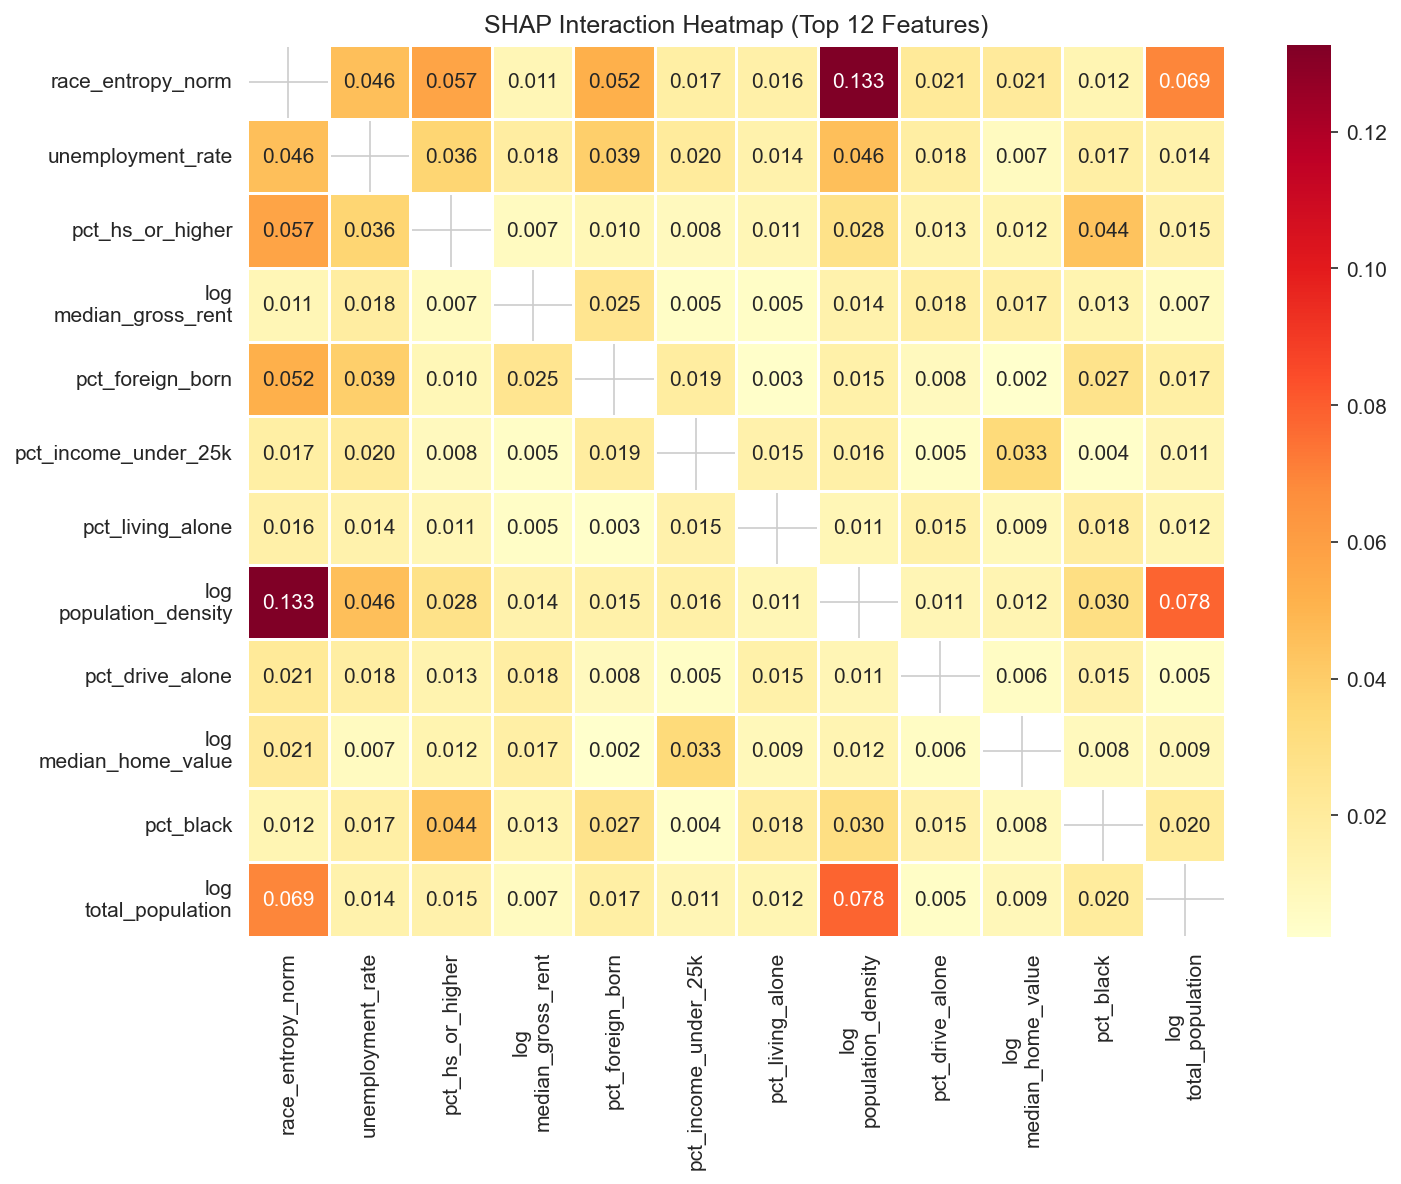

In [12]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_feat_idx = np.argsort(mean_abs_shap)[-12:][::-1]
top_feat_names = [feature_names[i] for i in top_feat_idx]

interaction_sub = interaction_df.loc[top_feat_names, top_feat_names]

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.eye(len(top_feat_names), dtype=bool)
sns.heatmap(interaction_sub, mask=mask, annot=True, fmt='.3f', cmap='YlOrRd',
            ax=ax, linewidths=0.5,
            xticklabels=[f.replace('log_', 'log\n') for f in top_feat_names],
            yticklabels=[f.replace('log_', 'log\n') for f in top_feat_names])
ax.set_title('SHAP Interaction Heatmap (Top 12 Features)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/deepdive_interaction_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Binary Classification — High vs Low Volatility

The 5-class problem is hard (F1~0.39). Collapsing to binary (Q4+Q5 vs Q1-Q3) gives a cleaner signal with ROC-AUC ~0.80.

### 4.1 Multiple Models — Binary Comparison

In [13]:
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)

binary_models = {
    'XGBoost': xgb.XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.1,
        subsample=0.8, random_state=RANDOM_STATE, verbosity=0, eval_metric='logloss'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_leaf=5,
        class_weight='balanced', random_state=RANDOM_STATE
    ),
    'SVM (Linear)': SVC(
        kernel='linear', C=1.0, class_weight='balanced',
        probability=True, random_state=RANDOM_STATE
    ),
    'SVM (RBF)': SVC(
        kernel='rbf', C=10.0, gamma='scale', class_weight='balanced',
        probability=True, random_state=RANDOM_STATE
    ),
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE
    )
}

binary_results = {}
print(f'Binary target: High (Q4+Q5) = {y_binary.sum()}, Low (Q1-Q3) = {(1-y_binary).sum()}')
print(f'\n{"Model":<20} {"Accuracy":>10} {"F1":>10} {"Precision":>10} {"Recall":>10} {"ROC-AUC":>10}')
print('-' * 72)

for name, model in binary_models.items():
    preds = cross_val_predict(model, X, y_binary, cv=cv)
    proba = cross_val_predict(model, X, y_binary, cv=cv, method='predict_proba')
    
    acc = accuracy_score(y_binary, preds)
    f1 = f1_score(y_binary, preds)
    prec = precision_score(y_binary, preds)
    rec = recall_score(y_binary, preds)
    auc = roc_auc_score(y_binary, proba[:, 1])
    
    binary_results[name] = {'acc': acc, 'f1': f1, 'prec': prec, 'rec': rec, 'auc': auc,
                            'preds': preds, 'proba': proba}
    print(f'{name:<20} {acc:>10.4f} {f1:>10.4f} {prec:>10.4f} {rec:>10.4f} {auc:>10.4f}')

Binary target: High (Q4+Q5) = 100, Low (Q1-Q3) = 150

Model                  Accuracy         F1  Precision     Recall    ROC-AUC
------------------------------------------------------------------------
XGBoost                  0.7480     0.6595     0.7176     0.6100     0.8138
Random Forest            0.7720     0.7077     0.7263     0.6900     0.8273
SVM (Linear)             0.6880     0.6100     0.6100     0.6100     0.7344
SVM (RBF)                0.7560     0.6738     0.7241     0.6300     0.7888
Logistic Regression      0.6800     0.6040     0.5980     0.6100     0.7453


### 4.2 ROC Curves — All Binary Models

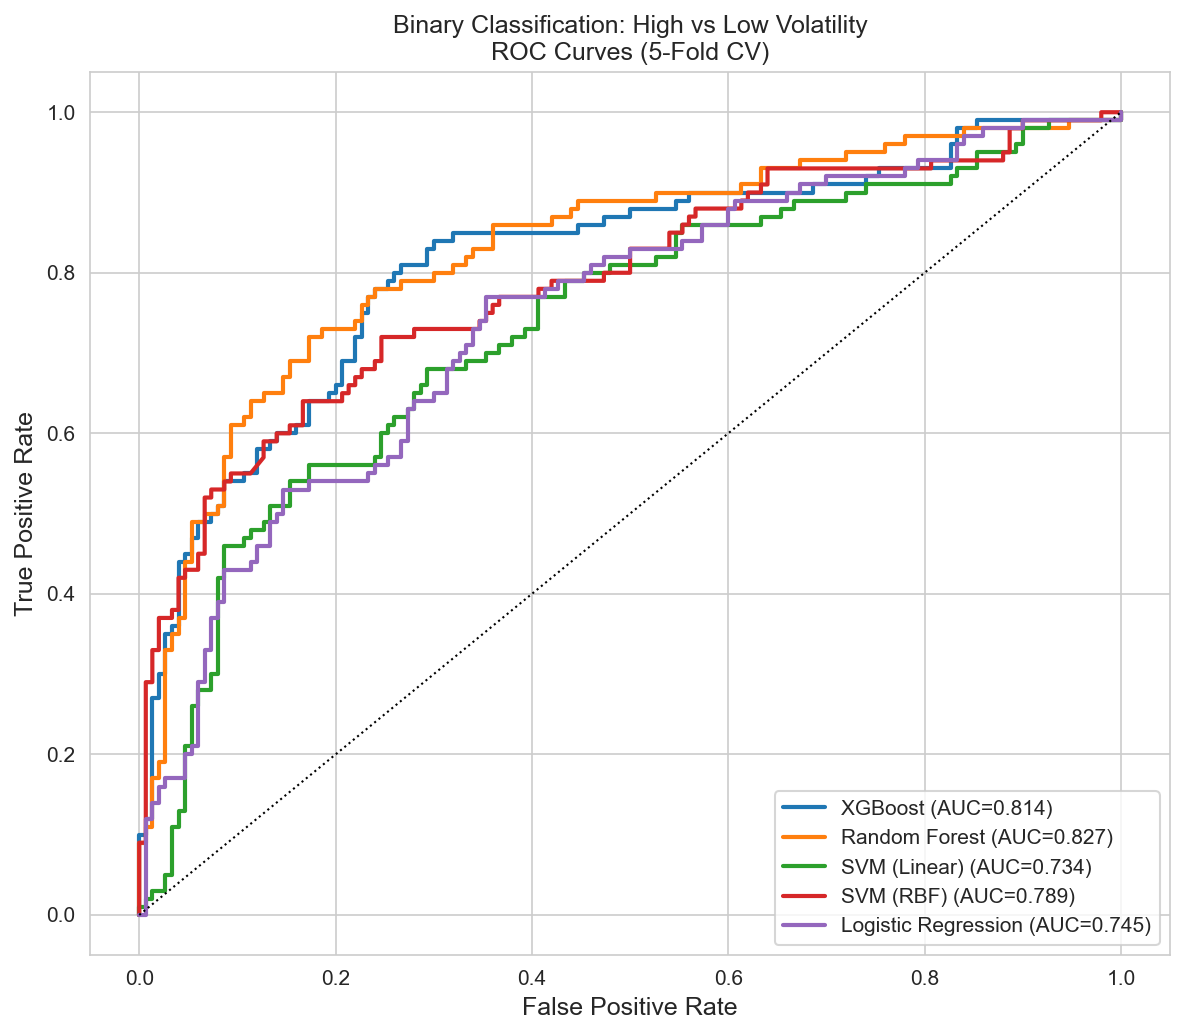

In [14]:
fig, ax = plt.subplots(figsize=(8, 7))
model_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for (name, res), color in zip(binary_results.items(), model_colors):
    fpr, tpr, _ = roc_curve(y_binary, res['proba'][:, 1])
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={res["auc"]:.3f})')

ax.plot([0, 1], [0, 1], 'k:', lw=1)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Binary Classification: High vs Low Volatility\nROC Curves (5-Fold CV)', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/deepdive_binary_roc_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Binary Confusion Matrices

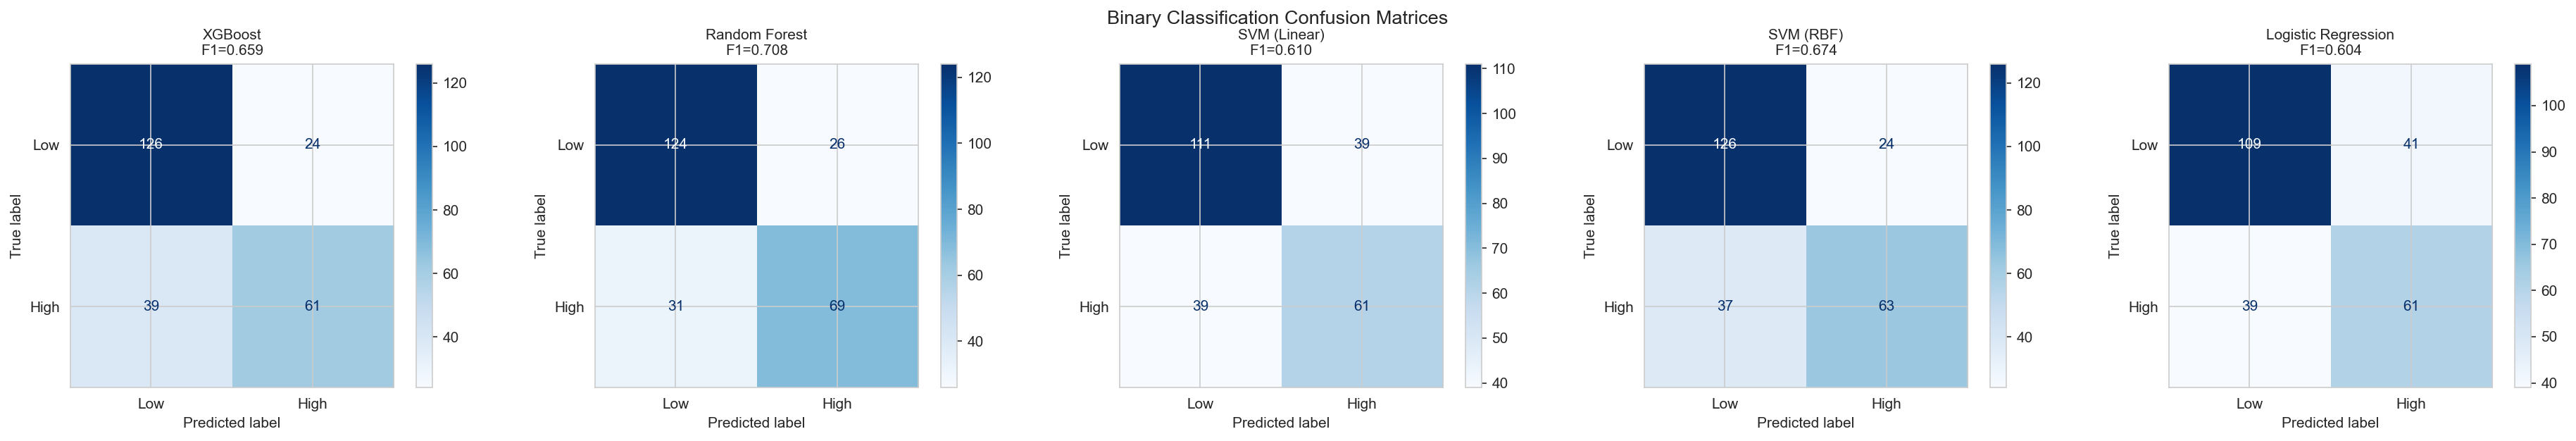

In [15]:
fig, axes = plt.subplots(1, 5, figsize=(25, 4))

for i, (name, res) in enumerate(binary_results.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_binary, res['preds'],
        display_labels=['Low', 'High'], cmap='Blues', ax=axes[i]
    )
    axes[i].set_title(f'{name}\nF1={res["f1"]:.3f}', fontsize=10)

plt.suptitle('Binary Classification Confusion Matrices', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/deepdive_binary_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Campaign Strategist View — Misfit x Volatility x Vote Volume

For campaign resource allocation, the most valuable counties are those that are:
1. **Demographically surprising** (misfit — unpredictable from demographics alone)
2. **Electorally volatile** (swinging between elections)
3. **High vote volume** (enough voters to actually flip outcomes)

### 5.1 Priority Score

In [16]:
from sklearn.preprocessing import MinMaxScaler

priority_df = df[['county_fips', 'state', 'county_name', 'total_population',
                   'total_votes', 'dem_margin', 'vol_z_abs_sum',
                   'misfit_score', 'p_dem', 'volatility_class']].copy()

priority_df['margin_closeness'] = (100 - priority_df['dem_margin'].abs()) / 100

norm_scaler = MinMaxScaler()
priority_df[['norm_volatility', 'norm_misfit', 'norm_votes', 'norm_closeness']] = norm_scaler.fit_transform(
    priority_df[['vol_z_abs_sum', 'misfit_score', 'total_votes', 'margin_closeness']]
)

priority_df['priority_score'] = (
    0.30 * priority_df['norm_volatility'] +
    0.25 * priority_df['norm_misfit'] +
    0.25 * priority_df['norm_votes'] +
    0.20 * priority_df['norm_closeness']
)

top_priority = priority_df.nlargest(25, 'priority_score')
print('=== Top 25 Priority Counties for Campaign Resource Allocation ===')
print(f'{"Rank":<5} {"County":<25} {"State":<6} {"Priority":>8} {"Volatility":>10} '
      f'{"Misfit":>8} {"Votes":>10} {"Margin":>8} {"Class":<16}')
print('-' * 100)
for rank, (_, row) in enumerate(top_priority.iterrows(), 1):
    print(f'{rank:<5} {row["county_name"]:<25} {row["state"]:<6} {row["priority_score"]:>8.3f} '
          f'{row["vol_z_abs_sum"]:>10.3f} {row["misfit_score"]:>8.3f} '
          f'{row["total_votes"]:>10,.0f} {row["dem_margin"]:>8.1f} {row["volatility_class"]}')

=== Top 25 Priority Counties for Campaign Resource Allocation ===
Rank  County                    State  Priority Volatility   Misfit      Votes   Margin Class           
----------------------------------------------------------------------------------------------------
1     Bucks County              PA        0.650      1.205    0.795    802,056     -0.1 Highly Volatile
2     Lackawanna County         PA        0.574      2.320    0.784    233,180      2.8 Highly Volatile
3     Cabarrus County           NC        0.570      2.619    0.866    120,202     -7.7 Highly Volatile
4     Leelanau County           MI        0.566      2.257    0.956     17,685      7.8 Highly Volatile
5     Scotland County           NC        0.561      3.995    0.739     14,626     -6.9 Highly Volatile
6     Marquette County          MI        0.547      1.588    0.956     39,009      8.7 Highly Volatile
7     Genesee County            MI        0.514      0.091    0.823    223,268      4.2 Volatile
8     M

### 5.2 Priority Scatter — 3D View

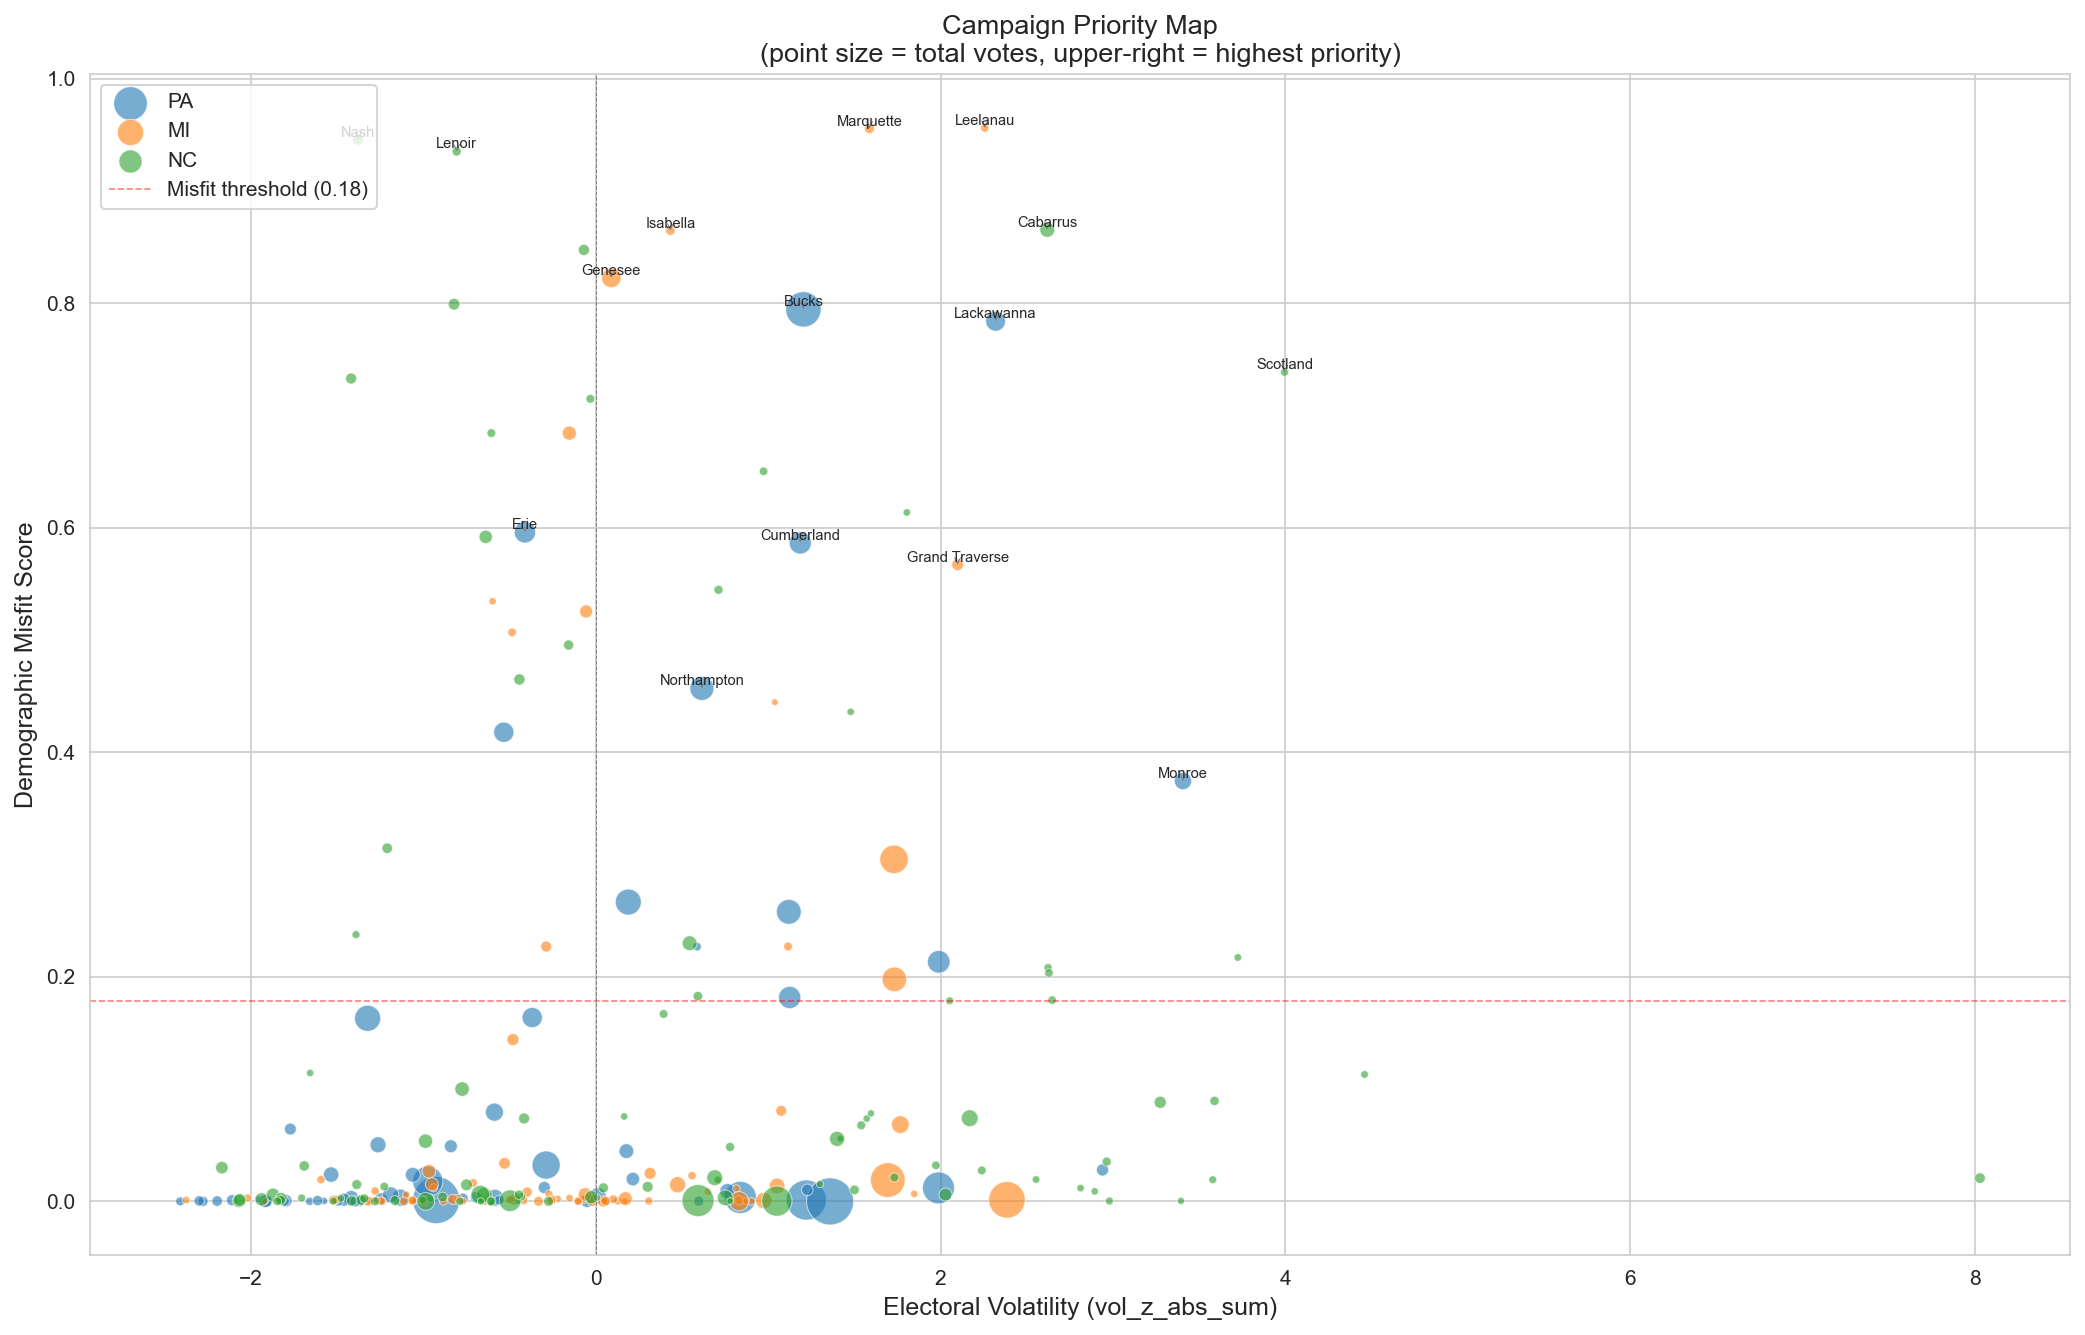

In [17]:
fig, ax = plt.subplots(figsize=(14, 9))

size_scale = (priority_df['total_votes'] / priority_df['total_votes'].max()) * 500 + 10
colors_state = {'PA': '#1f77b4', 'MI': '#ff7f0e', 'NC': '#2ca02c'}

for state_name, color in colors_state.items():
    mask = priority_df['state'] == state_name
    ax.scatter(
        priority_df.loc[mask, 'vol_z_abs_sum'],
        priority_df.loc[mask, 'misfit_score'],
        s=size_scale[mask],
        c=color, alpha=0.6, edgecolors='white', linewidth=0.5,
        label=state_name
    )

for _, row in top_priority.head(15).iterrows():
    ax.annotate(
        row['county_name'].replace(' County', ''),
        (row['vol_z_abs_sum'], row['misfit_score']),
        fontsize=7, ha='center', va='bottom',
        arrowprops=dict(arrowstyle='->', color='gray', lw=0.5)
    )

ax.axhline(y=misfit_threshold, color='red', linestyle='--', linewidth=0.8, alpha=0.5, label=f'Misfit threshold ({misfit_threshold:.2f})')
ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.5)

ax.set_xlabel('Electoral Volatility (vol_z_abs_sum)', fontsize=12)
ax.set_ylabel('Demographic Misfit Score', fontsize=12)
ax.set_title('Campaign Priority Map\n(point size = total votes, upper-right = highest priority)', fontsize=13)
ax.legend(fontsize=10, loc='upper left')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/deepdive_campaign_priority_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Priority by State

In [18]:
print('=== Top 10 Priority Counties Per State ===')
for state_name in ['PA', 'MI', 'NC']:
    state_top = priority_df[priority_df['state'] == state_name].nlargest(10, 'priority_score')
    print(f'\n--- {state_name} ---')
    for rank, (_, row) in enumerate(state_top.iterrows(), 1):
        print(f'  {rank}. {row["county_name"]} — priority={row["priority_score"]:.3f}, '
              f'votes={row["total_votes"]:,.0f}, margin={row["dem_margin"]:+.1f}, '
              f'volatility={row["volatility_class"]}')

=== Top 10 Priority Counties Per State ===

--- PA ---
  1. Bucks County — priority=0.650, votes=802,056, margin=-0.1, volatility=Highly Volatile
  2. Lackawanna County — priority=0.574, votes=233,180, margin=+2.8, volatility=Highly Volatile
  3. Monroe County — priority=0.492, votes=171,050, margin=-0.8, volatility=Highly Volatile
  4. Cumberland County — priority=0.482, votes=296,792, margin=-9.4, volatility=Volatile
  5. Northampton County — priority=0.463, votes=356,430, margin=-1.8, volatility=Volatile
  6. Erie County — priority=0.458, votes=275,190, margin=-1.0, volatility=Moderate
  7. Allegheny County — priority=0.437, votes=1,441,008, margin=+20.3, volatility=Stable
  8. Lehigh County — priority=0.427, votes=379,620, margin=+2.7, volatility=Volatile
  9. Montgomery County — priority=0.422, votes=1,041,812, margin=+22.8, volatility=Highly Volatile
  10. Chester County — priority=0.402, votes=649,928, margin=+14.5, volatility=Highly Volatile

--- MI ---
  1. Leelanau County — p

### 5.4 Save Priority Rankings

In [19]:
priority_export = priority_df.sort_values('priority_score', ascending=False)
priority_export.to_csv(f'{BASE}/campaign_priority_rankings.csv', index=False)
print(f'Saved: {BASE}/campaign_priority_rankings.csv ({priority_export.shape})')

Saved: ../data/processed/campaign_priority_rankings.csv ((250, 16))


---
## 6. Nonlinear Deep-Dives

The SHAP dependence plots showed interesting nonlinear relationships. Let's explore them more carefully.

### 6.1 Rent-Volatility Relationship (Top SHAP Feature)

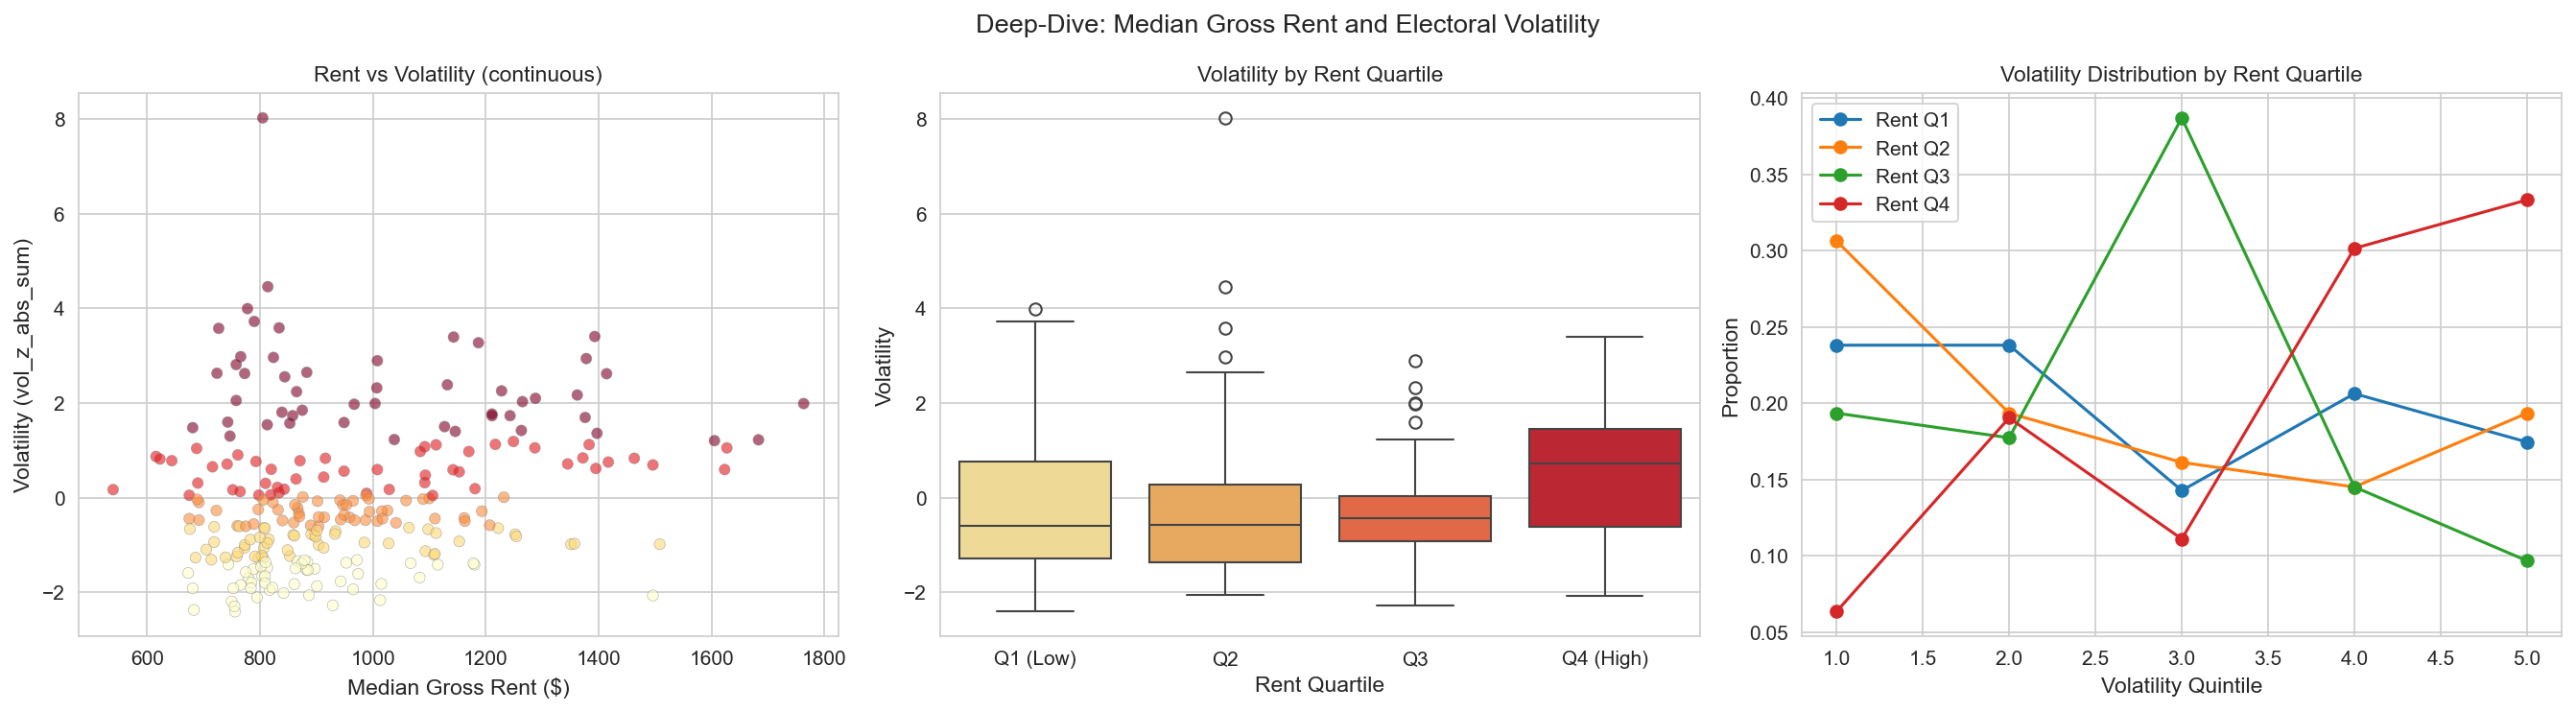

Rent vs Volatility: Pearson r=0.220 (p=0.0005), Spearman rho=0.228 (p=0.0003)


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

rent_col = 'median_gross_rent' if 'median_gross_rent' in df.columns else 'log_median_gross_rent'
rent_vals = df['median_gross_rent'] if 'median_gross_rent' in df.columns else np.expm1(X_unscaled['log_median_gross_rent'])

axes[0].scatter(rent_vals, df['vol_z_abs_sum'], c=df['vol_quintile_num'],
                cmap='YlOrRd', s=30, alpha=0.6, edgecolors='gray', linewidth=0.3)
axes[0].set_xlabel('Median Gross Rent ($)', fontsize=11)
axes[0].set_ylabel('Volatility (vol_z_abs_sum)', fontsize=11)
axes[0].set_title('Rent vs Volatility (continuous)', fontsize=11)

rent_quartiles = pd.qcut(rent_vals, q=4, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'])
sns.boxplot(x=rent_quartiles, y=df['vol_z_abs_sum'], ax=axes[1], palette='YlOrRd')
axes[1].set_xlabel('Rent Quartile', fontsize=11)
axes[1].set_ylabel('Volatility', fontsize=11)
axes[1].set_title('Volatility by Rent Quartile', fontsize=11)

rent_q = pd.qcut(rent_vals, q=4, labels=False)
for rq in range(4):
    mask_rq = rent_q == rq
    vol_class_dist = df.loc[mask_rq, 'vol_quintile_num'].value_counts(normalize=True).sort_index()
    axes[2].plot(vol_class_dist.index, vol_class_dist.values,
                 marker='o', label=f'Rent Q{rq+1}')
axes[2].set_xlabel('Volatility Quintile', fontsize=11)
axes[2].set_ylabel('Proportion', fontsize=11)
axes[2].set_title('Volatility Distribution by Rent Quartile', fontsize=11)
axes[2].legend()

plt.suptitle('Deep-Dive: Median Gross Rent and Electoral Volatility', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/deepdive_rent_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

r_rent, p_rent = pearsonr(rent_vals, df['vol_z_abs_sum'])
rho_rent, p_rho = spearmanr(rent_vals, df['vol_z_abs_sum'])
print(f'Rent vs Volatility: Pearson r={r_rent:.3f} (p={p_rent:.4f}), Spearman rho={rho_rent:.3f} (p={p_rho:.4f})')

### 6.2 Diversity-Poverty Interaction

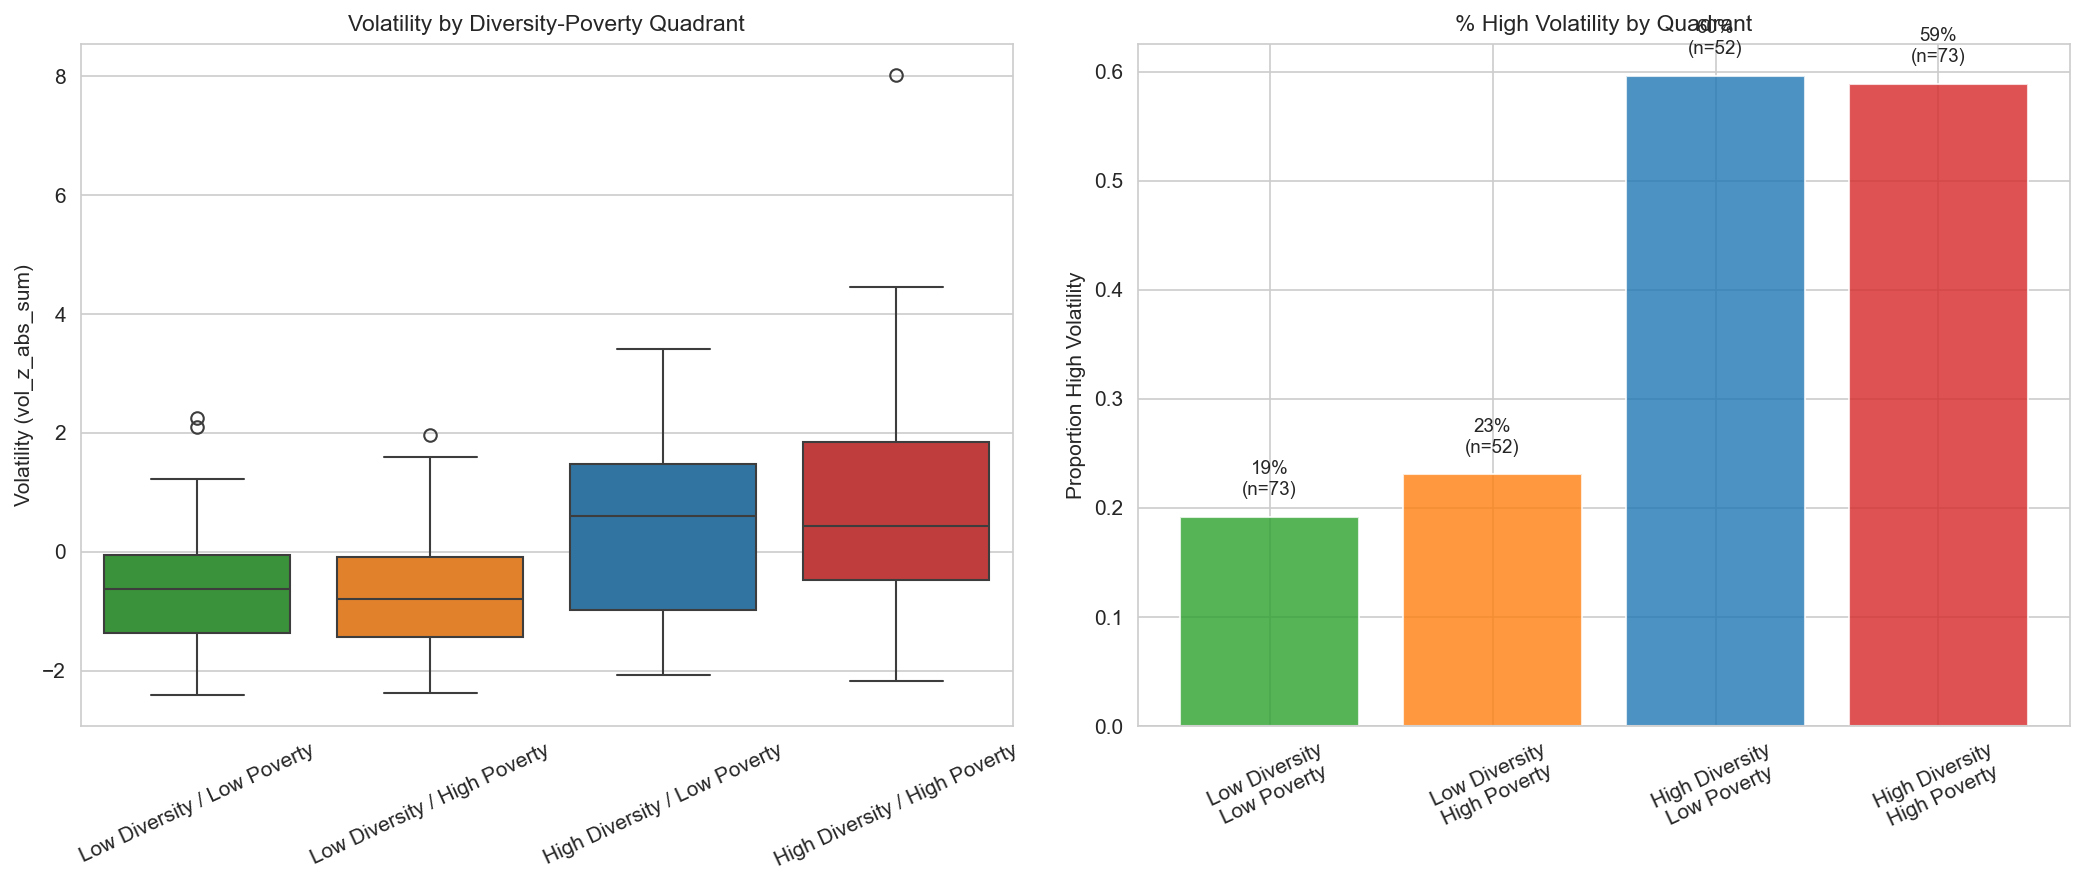


Quadrant statistics:
  Low Diversity / Low Poverty: n=73, mean_vol=-0.622, %high_vol=19.2%, %misfit=11.0%
  Low Diversity / High Poverty: n=52, mean_vol=-0.669, %high_vol=23.1%, %misfit=7.7%
  High Diversity / Low Poverty: n=52, mean_vol=0.407, %high_vol=59.6%, %misfit=26.9%
  High Diversity / High Poverty: n=73, mean_vol=0.808, %high_vol=58.9%, %misfit=32.9%


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

entropy_med = df['race_entropy_norm'].median()
poverty_med = df['pct_below_poverty'].median()

df['diversity_group'] = np.where(df['race_entropy_norm'] >= entropy_med, 'High Diversity', 'Low Diversity')
df['poverty_group'] = np.where(df['pct_below_poverty'] >= poverty_med, 'High Poverty', 'Low Poverty')
df['quadrant'] = df['diversity_group'] + ' / ' + df['poverty_group']

quad_order = ['Low Diversity / Low Poverty', 'Low Diversity / High Poverty',
              'High Diversity / Low Poverty', 'High Diversity / High Poverty']
quad_colors = ['#2ca02c', '#ff7f0e', '#1f77b4', '#d62728']

sns.boxplot(data=df, x='quadrant', y='vol_z_abs_sum', order=quad_order,
            palette=quad_colors, ax=axes[0])
axes[0].set_title('Volatility by Diversity-Poverty Quadrant', fontsize=11)
axes[0].set_xlabel('')
axes[0].set_ylabel('Volatility (vol_z_abs_sum)')
axes[0].tick_params(axis='x', rotation=25)

for quad, color in zip(quad_order, quad_colors):
    mask_q = df['quadrant'] == quad
    n_q = mask_q.sum()
    pct_high = df.loc[mask_q, 'vol_binary'].mean()
    axes[1].bar(quad.replace(' / ', '\n'), pct_high, color=color, alpha=0.8)
    axes[1].text(list(zip(quad_order, quad_colors)).index((quad, color)),
                 pct_high + 0.02, f'{pct_high:.0%}\n(n={n_q})', ha='center', fontsize=9)

axes[1].set_title('% High Volatility by Quadrant', fontsize=11)
axes[1].set_ylabel('Proportion High Volatility')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/deepdive_diversity_poverty_interaction.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nQuadrant statistics:')
for quad in quad_order:
    mask_q = df['quadrant'] == quad
    print(f'  {quad}: n={mask_q.sum()}, '
          f'mean_vol={df.loc[mask_q, "vol_z_abs_sum"].mean():.3f}, '
          f'%high_vol={df.loc[mask_q, "vol_binary"].mean():.1%}, '
          f'%misfit={df.loc[mask_q, "is_misfit"].mean():.1%}')

### 6.3 Education-Urbanization Interaction

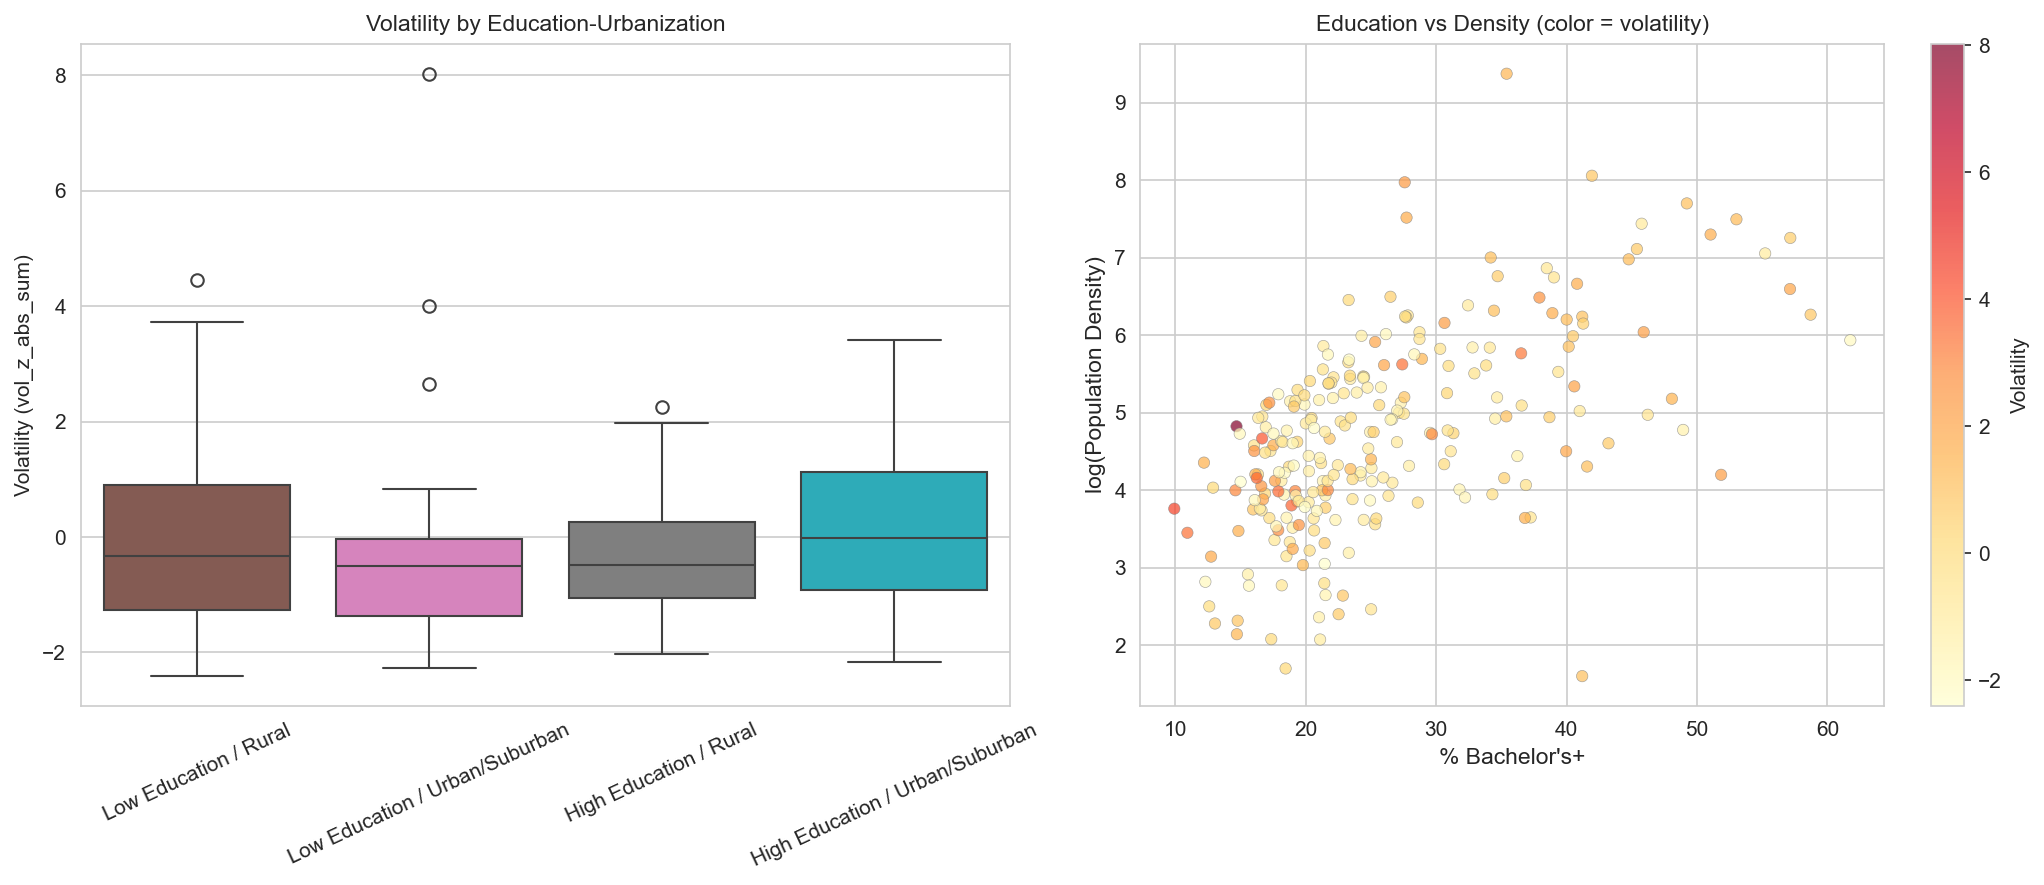


Education-Urbanization quadrant stats:
  Low Education / Rural: n=89, mean_vol=0.048, %high_vol=41.6%
  Low Education / Urban/Suburban: n=36, mean_vol=-0.288, %high_vol=19.4%
  High Education / Rural: n=36, mean_vol=-0.272, %high_vol=33.3%
  High Education / Urban/Suburban: n=89, mean_vol=0.178, %high_vol=49.4%


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ed_med = df['pct_bachelors_plus'].median()
pop_dens = df['population_density']
dens_med = pop_dens.median()

df['ed_group'] = np.where(df['pct_bachelors_plus'] >= ed_med, 'High Education', 'Low Education')
df['urban_group'] = np.where(pop_dens >= dens_med, 'Urban/Suburban', 'Rural')
df['ed_urban_quad'] = df['ed_group'] + ' / ' + df['urban_group']

eu_order = ['Low Education / Rural', 'Low Education / Urban/Suburban',
            'High Education / Rural', 'High Education / Urban/Suburban']
eu_colors = ['#8c564b', '#e377c2', '#7f7f7f', '#17becf']

sns.boxplot(data=df, x='ed_urban_quad', y='vol_z_abs_sum', order=eu_order,
            palette=eu_colors, ax=axes[0])
axes[0].set_title('Volatility by Education-Urbanization', fontsize=11)
axes[0].set_xlabel('')
axes[0].set_ylabel('Volatility (vol_z_abs_sum)')
axes[0].tick_params(axis='x', rotation=25)

scatter = axes[1].scatter(
    df['pct_bachelors_plus'], np.log1p(pop_dens),
    c=df['vol_z_abs_sum'], cmap='YlOrRd', s=30, alpha=0.7, edgecolors='gray', linewidth=0.3
)
axes[1].set_xlabel('% Bachelor\'s+', fontsize=11)
axes[1].set_ylabel('log(Population Density)', fontsize=11)
axes[1].set_title('Education vs Density (color = volatility)', fontsize=11)
plt.colorbar(scatter, ax=axes[1], label='Volatility')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/deepdive_education_urbanization.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nEducation-Urbanization quadrant stats:')
for quad in eu_order:
    mask_q = df['ed_urban_quad'] == quad
    print(f'  {quad}: n={mask_q.sum()}, mean_vol={df.loc[mask_q, "vol_z_abs_sum"].mean():.3f}, '
          f'%high_vol={df.loc[mask_q, "vol_binary"].mean():.1%}')

### 6.4 SHAP Waterfall — Case Studies of Interesting Counties

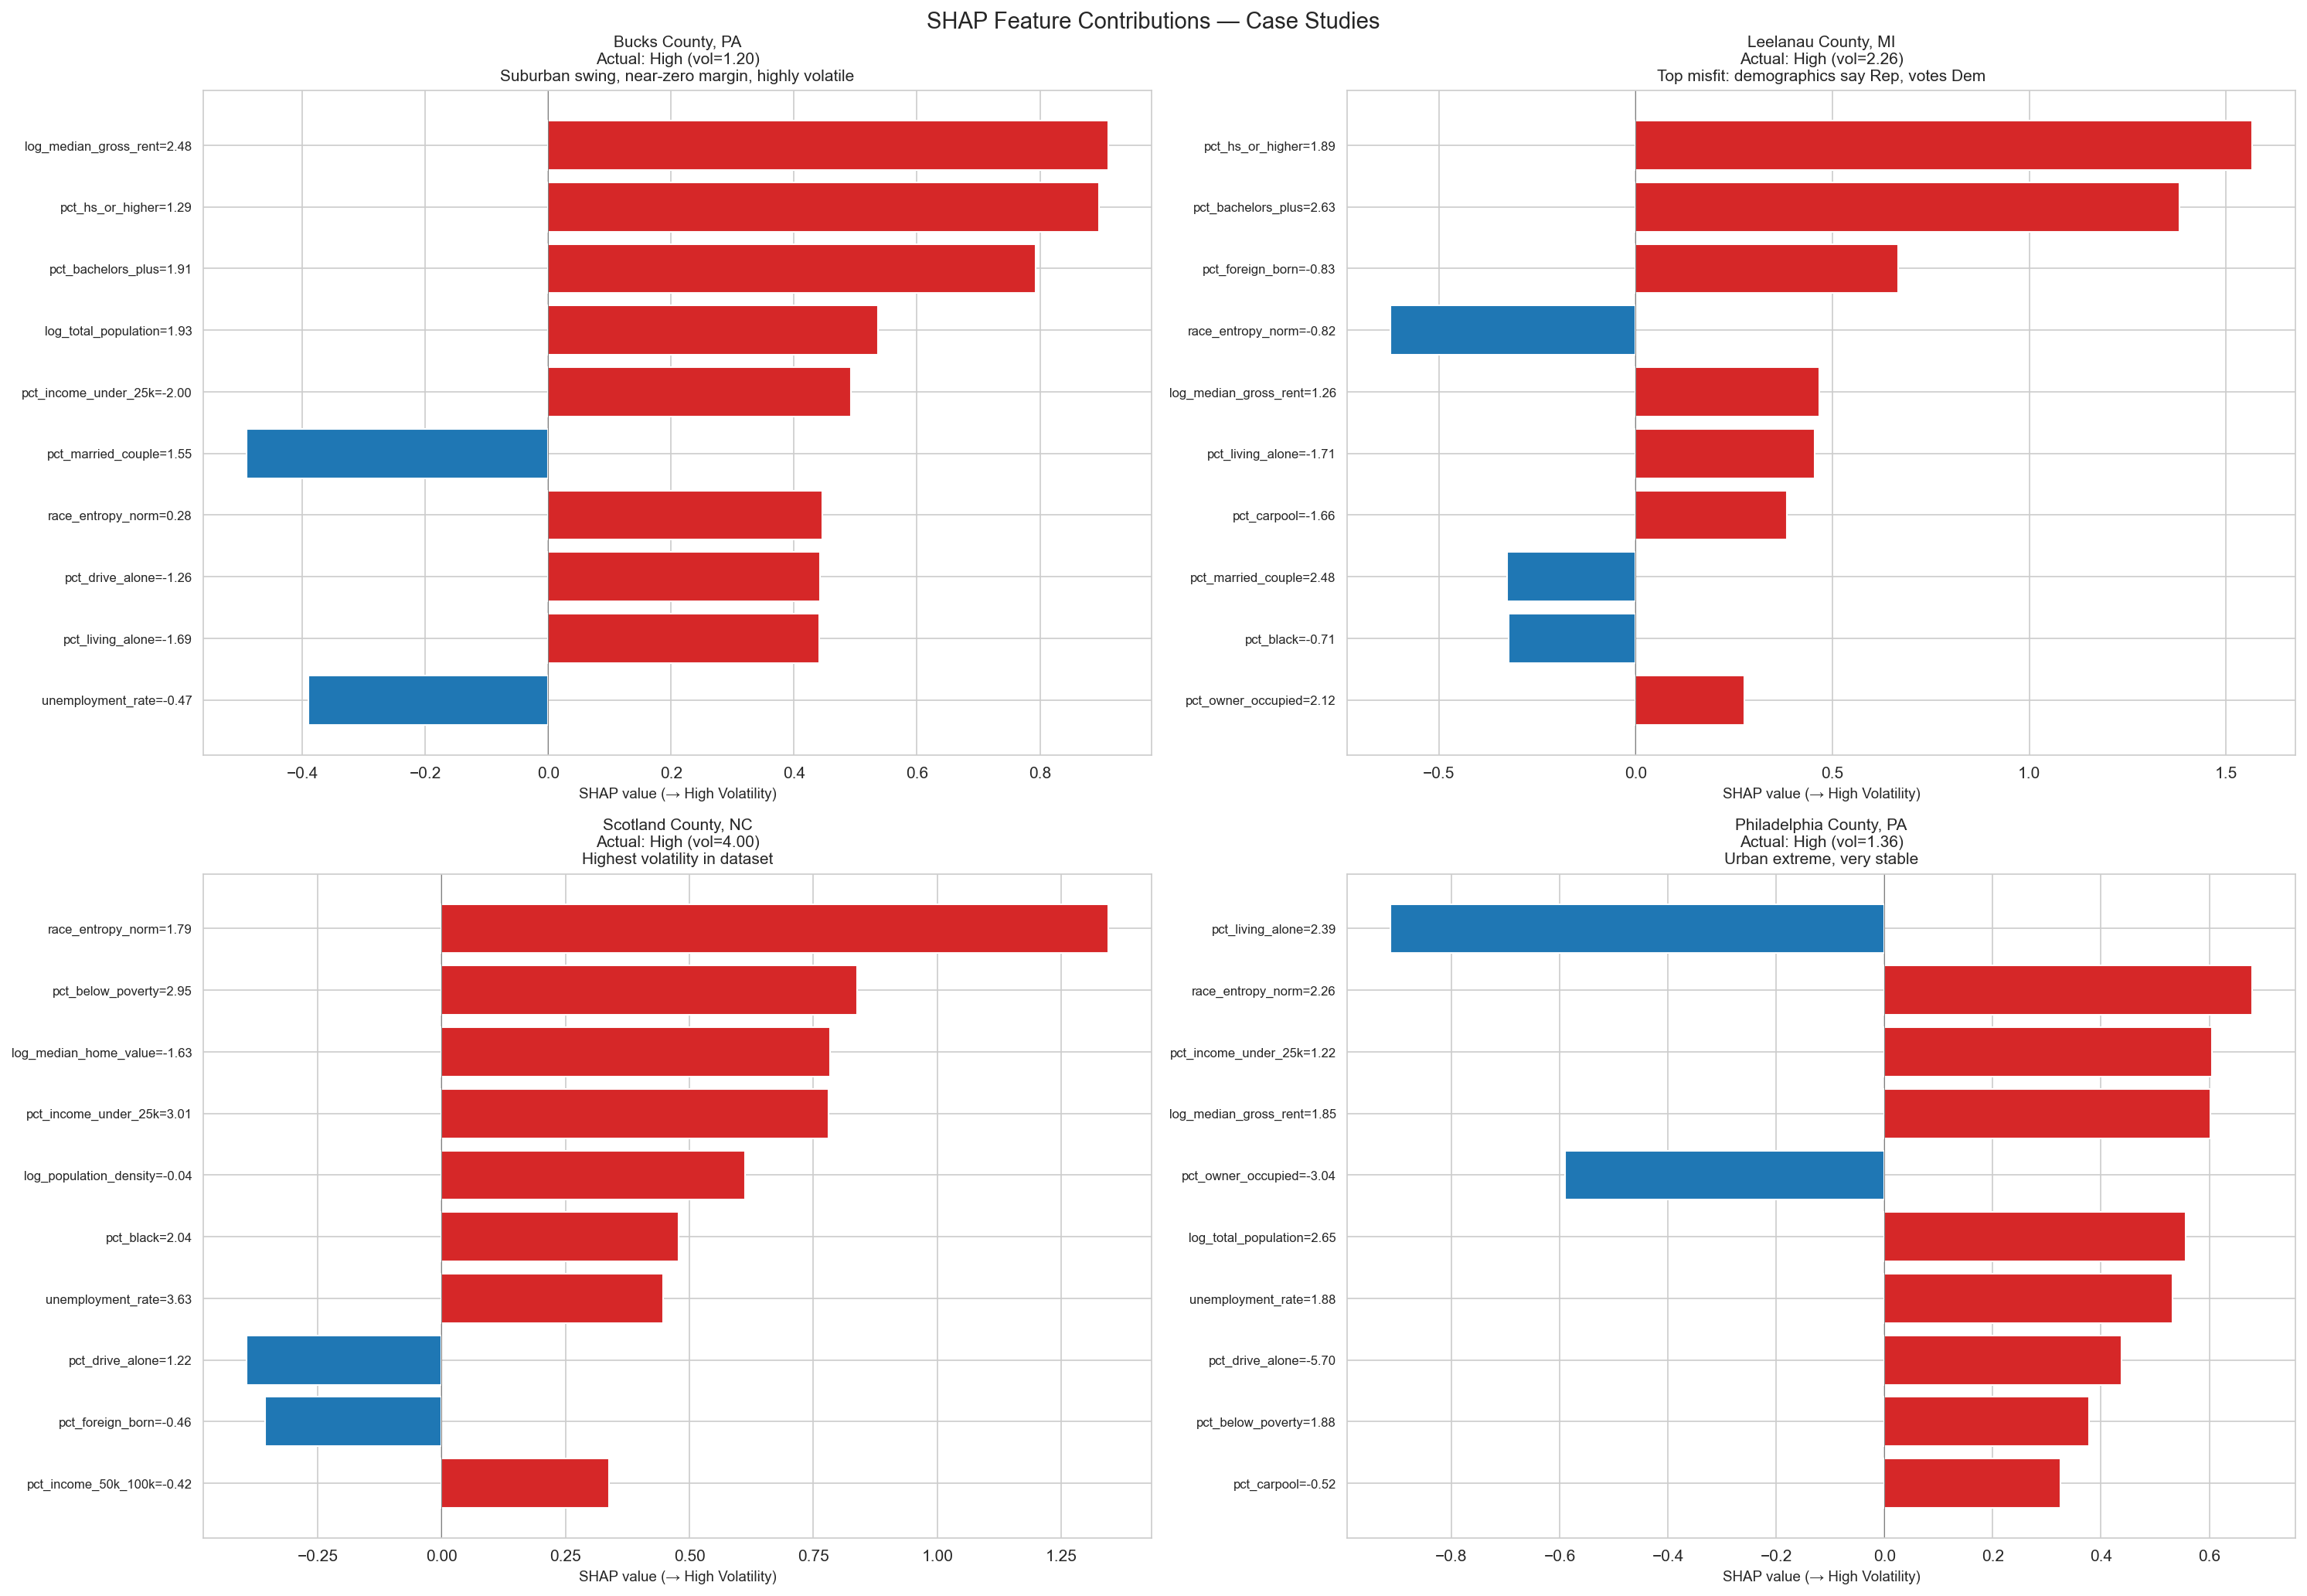

In [23]:
case_counties = [
    ('Bucks County', 'PA', 'Suburban swing, near-zero margin, highly volatile'),
    ('Leelanau County', 'MI', 'Top misfit: demographics say Rep, votes Dem'),
    ('Scotland County', 'NC', 'Highest volatility in dataset'),
    ('Philadelphia County', 'PA', 'Urban extreme, very stable')
]

xgb_binary.fit(X, y_binary)
explainer_binary = shap.TreeExplainer(xgb_binary)
shap_vals_binary = explainer_binary(X)

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

for idx, (county, state, desc) in enumerate(case_counties):
    county_mask = (df['county_name'] == county) & (df['state'] == state)
    if county_mask.sum() == 0:
        print(f'County not found: {county}, {state}')
        continue
    
    county_idx = county_mask.idxmax()
    actual = 'High' if y_binary[county_idx] == 1 else 'Low'
    vol_val = df.loc[county_idx, 'vol_z_abs_sum']
    
    sv = shap_vals_binary[county_idx]
    top_feat_idx = np.argsort(np.abs(sv.values))[-10:][::-1]
    
    ax = axes[idx // 2, idx % 2]
    feat_vals = sv.values[top_feat_idx]
    feat_labels = [feature_names[i] for i in top_feat_idx]
    colors_bar = ['#d62728' if v > 0 else '#1f77b4' for v in feat_vals]
    
    ax.barh(range(len(feat_vals)), feat_vals, color=colors_bar)
    ax.set_yticks(range(len(feat_vals)))
    ax.set_yticklabels([f'{fn}={X.iloc[county_idx][fn]:.2f}' for fn in feat_labels], fontsize=8)
    ax.axvline(x=0, color='gray', linewidth=0.5)
    ax.set_xlabel('SHAP value (→ High Volatility)', fontsize=9)
    ax.set_title(f'{county}, {state}\nActual: {actual} (vol={vol_val:.2f})\n{desc}', fontsize=10)
    ax.invert_yaxis()

plt.suptitle('SHAP Feature Contributions — Case Studies', fontsize=14)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/deepdive_shap_case_studies.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Summary of Deep-Dive Findings

In [24]:
print('=' * 70)
print('DEEP-DIVE ANALYSIS — KEY FINDINGS SUMMARY')
print('=' * 70)

print('\n1. WHY MISFITS ARE VOLATILE:')
print('   - Misfits have higher racial diversity, more poverty,')
print('     and more variable household structures')
print('   - "Surprise Dem" misfits (demographics say Rep, votes Dem)')
print('     tend to be university/resort towns with unique electorates')
print('   - "Surprise Rep" misfits tend to be Southern counties')
print('     with mixed demographics but strong cultural conservatism')

print('\n2. STATE-SPECIFIC MODELS:')
for s in ['PA', 'MI', 'NC']:
    r = state_results[s]
    print(f'   - {s}: AUC={r["auc"]:.3f}, F1={r["f1"]:.3f} (n={r["n"]})')
print('   - Different features matter in each state')

print('\n3. SHAP INTERACTIONS:')
print(f'   - Top interaction: {top_interactions[0][0]} x {top_interactions[0][1]}')
print(f'     (interaction value: {top_interactions[0][2]:.4f})')
print('   - Feature combinations reveal volatility patterns')
print('     not visible from individual features alone')

print('\n4. BINARY CLASSIFICATION (High vs Low Volatility):')
best_binary = max(binary_results.items(), key=lambda x: x[1]['auc'])
print(f'   - Best model: {best_binary[0]} (AUC={best_binary[1]["auc"]:.3f})')
print('   - Much cleaner signal than 5-class problem')

print('\n5. CAMPAIGN PRIORITY RANKINGS:')
print(f'   - Top priority: {top_priority.iloc[0]["county_name"]} ({top_priority.iloc[0]["state"]})')
print(f'   - Saved to: {BASE}/campaign_priority_rankings.csv')

print('\n6. NONLINEAR FINDINGS:')
print(f'   - Rent vs Volatility: Pearson r={r_rent:.3f}, Spearman rho={rho_rent:.3f}')
print('   - High-diversity + High-poverty counties are most volatile')
print('   - Education-urbanization interaction shapes volatility patterns')

print('\n' + '=' * 70)
print('All figures saved to docs/images/methods/')
print('Priority rankings saved to data/processed/campaign_priority_rankings.csv')

DEEP-DIVE ANALYSIS — KEY FINDINGS SUMMARY

1. WHY MISFITS ARE VOLATILE:
   - Misfits have higher racial diversity, more poverty,
     and more variable household structures
   - "Surprise Dem" misfits (demographics say Rep, votes Dem)
     tend to be university/resort towns with unique electorates
   - "Surprise Rep" misfits tend to be Southern counties
     with mixed demographics but strong cultural conservatism

2. STATE-SPECIFIC MODELS:
   - PA: AUC=0.838, F1=0.591 (n=67)
   - MI: AUC=0.778, F1=0.636 (n=83)
   - NC: AUC=0.829, F1=0.736 (n=100)
   - Different features matter in each state

3. SHAP INTERACTIONS:
   - Top interaction: race_entropy_norm x log_population_density
     (interaction value: 0.1328)
   - Feature combinations reveal volatility patterns
     not visible from individual features alone

4. BINARY CLASSIFICATION (High vs Low Volatility):
   - Best model: Random Forest (AUC=0.827)
   - Much cleaner signal than 5-class problem

5. CAMPAIGN PRIORITY RANKINGS:
   - T